In [35]:
import requests

# 기본 URL 설정
base_url = "https://www.lotteshopping.com/store/typeDetailAjax"

# 카테고리 코드 설정
category_codes = [
    "010000",  # 여성패션
    "020000",  # 영패션
    # 추가 카테고리 코드
]

# 헤더 설정
headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.lotteshopping.com/store/type?cstrCd=0352",  # 필요 시 추가
    "X-Requested-With": "XMLHttpRequest"  # AJAX 요청임을 명시
}

# 카테고리별 데이터 가져오기
for code in category_codes:
    params = {
        "cstrCd": "0352",  # 매장 코드
        "cstrTownCd": "",
        "lrclsCd": code,
    }

    response = requests.get(base_url, params=params, headers=headers)

    # 응답 내용 확인
    if response.status_code == 200:
        try:
            data = response.json()  # JSON 데이터가 반환된다고 가정
            print(f"\n--- 카테고리 코드 {code} 데이터 ---")
            for item in data['brand_list']:  # JSON 구조에 맞게 수정
                print(item['name'])
        except requests.JSONDecodeError:
            print(f"JSON 디코딩 실패. 응답 내용:\n{response.text}")
    else:
        print(f"카테고리 코드 {code} 데이터 가져오기 실패. 상태 코드: {response.status_code}")

JSON 디코딩 실패. 응답 내용:
<div class="__type-title">
    <span class="s-title7-m">여성패션</span>
</div>

<ul class="__category-list list-underline" list-size="sm" responsive drag-list>
    <li category-type="all" onclick="showAllBlockTabTitle();" class="active"><span>전체</span></li>
    <li category-type="여성캐주얼" class="">
            <span>여성캐주얼</span>
        </li>
    <li category-type="여성정장" class="">
            <span>여성정장</span>
        </li>
    <li category-type="영캐주얼" class="">
            <span>영캐주얼</span>
        </li>
    </ul>

<div class="__category-item">
    <h5 class="__block-title s-title7-b" data-cstrTownNm="본동"
                data-mdclses="여성캐주얼,여성정장,영캐주얼">
            본동</h5>
        <div category-type="여성캐주얼" class="active">
                <div class="__item-wrap">
                        <div class="__item-title c-title2-m">여성캐주얼</div>
                        <ul class="__item-list">
                            <li class="__item" cursor-more
                              

In [36]:
import requests
from bs4 import BeautifulSoup

# 카테고리 코드와 이름 설정
categories = {
    "010000": "여성패션",
    "020000": "영패션",
    "040000": "패션 액세서리",
    "050000": "화장품",
    "060000": "남성패션",
    "070000": "레져/스포츠",
    "080000": "아동/유아",
    "090000": "해외패션",
    "100000": "리빙/가전",
    "110000": "식품관",
    "120000": "F&B",
    "150000": "엔터테인먼트",
    "130000": "행사장",
    "140000": "편의시설",
}

# 헤더 설정
headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.lotteshopping.com/store/type?cstrCd=0352",
    "X-Requested-With": "XMLHttpRequest"
}

# 카테고리별 데이터 가져오기
for code, category_name in categories.items():
    params = {
        "cstrCd": "0352",  # 매장 코드
        "cstrTownCd": "",  # 필요한 경우 설정
        "lrclsCd": code,   # 카테고리 코드
    }

    response = requests.get(base_url, params=params, headers=headers)

    subcategory_name_info = []
    brand_info = []
    floor_table = []

    # 응답이 HTML인 경우 BeautifulSoup로 파싱
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        
        print(f"\n--- {category_name} ---")
        
        # 하위 카테고리별 브랜드 및 층수 정보 추출
        subcategories = soup.select("div.__item-wrap")
        for subcategory in subcategories:
            # 하위 카테고리명 (예: "여성캐주얼")
            subcategory_name = subcategory.select_one("div.__item-title.c-title2-m").text.strip()
            subcategory_name_info.append([subcategory_name])
            print(f"\n하위 카테고리: {subcategory_name}")

            # 각 브랜드와 층수 정보 추출
            items = subcategory.select("li.__item")
            for item in items:
                brand = item.select_one("div.__brand.c-body2-m")
                floor = item.select_one("div.__desc.c-body2-r span")

                brand_name = brand.text.strip() if brand else "브랜드 정보 없음"
                floor_info = floor.text.strip() if floor else "층수 정보 없음"

                brand_info.append([brand])
                floor_table.append([floor])

                print(f"  {brand_name}, {floor_info}")
            
    else:
        print(f"{category_name} 데이터 가져오기 실패. 상태 코드: {response.status_code}")


--- 여성패션 ---

하위 카테고리: 여성캐주얼
  기비/보니페이, 2F
  더아이잗컬렉션, 2F
  데무, 2F
  데코, 2F
  모에, 2F
  미샤, 2F
  비너스, 2F
  비비안, 2F
  쁘렝땅, 2F
  쉬즈미스, 2F
  아이잗바바, 2F
  와코루, 2F
  이새, 2F
  지고트, 2F
  컴젠, 2F
  코데즈컴바인 이너웨어, 2F
  키이스/블룸스버리, 2F
  BCBG, 2F
  끌로디피에로, 1F
  더캐시미어, 1F
  데바스테, 1F
  띠어리, 1F
  랑방컬렉션, 1F
  래트, 1F
  마인, 1F
  모조에스핀, 1F
  바네사브루노, 1F
  베르니스, 1F
  비이커, 1F
  빔바이롤라, 1F
  산드로, 1F
  오브제, 1F
  이로, 1F
  쟈딕앤볼테르, 1F
  질스튜어트, 1F
  클럽모나코, 1F
  타임, 1F
  탐그레이하운드, 1F
  DKNY, 1F
  ssf.BUSAN(삼성물산편집샵), 1F

하위 카테고리: 여성정장
  진도모피, 2F

하위 카테고리: 영캐주얼
  나이스크랍, 2F
  나인, 2F
  듀엘, 2F
  라인, 2F
  러브앤쇼, 2F
  럭키슈에뜨, 2F
  르샵, 2F
  리스트, 2F
  베네통, 2F
  보브, 2F
  뷰어, 2F
  스튜디오톰보이, 2F
  시스템, 2F
  시스티나, 2F
  시슬리, 2F
  써스데이아일랜드, 2F
  씨씨콜렉트, 2F
  에고이스트, 2F
  에스제이, 2F
  오즈세컨, 2F
  온앤온, 2F
  올리브데올리브, 2F
  잇미샤, 2F
  제이제이지고트, 2F
  지컷, 2F
  케네스레이디, 2F
  파슨스, 2F
  플라스틱아일랜드, 2F
  ZOOC, 2F

하위 카테고리: 영캐주얼
  스튜디오 샵, 2F
  알엔, 2F
  HAGO, 1F

--- 영패션 ---

하위 카테고리: SPA/Street
  랩, 2F
  반에이크, 2F
  트위, 2F
  피그먼트, 2F

하위 카테고리: 진/유니캐주얼
  마인드브릿지, 

In [10]:
import pandas as pd

In [46]:
if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        
        print(f"\n--- {category_name} ---")


--- 편의시설 ---


In [52]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 카테고리 코드와 이름 설정
categories = {
    "010000": "여성패션",
    "020000": "영패션",
    "040000": "패션 액세서리",
    "050000": "화장품",
    "060000": "남성패션",
    "070000": "레져/스포츠",
    "080000": "아동/유아",
    "090000": "해외패션",
    "100000": "리빙/가전",
    "110000": "식품관",
    "120000": "F&B",
    "150000": "엔터테인먼트",
    "130000": "행사장",
    "140000": "편의시설",
}

# 헤더 설정
headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.lotteshopping.com/store/type?cstrCd=0352",
    "X-Requested-With": "XMLHttpRequest"
}

# 데이터 저장용 리스트
data = []

# 카테고리별 데이터 가져오기
for code, category_name in categories.items():
    params = {
        "cstrCd": "0352",  # 매장 코드
        "cstrTownCd": "",  # 필요한 경우 설정
        "lrclsCd": code,   # 카테고리 코드
    }

    response = requests.get(base_url, params=params, headers=headers)

    # 응답이 HTML인 경우 BeautifulSoup로 파싱
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        
        
        # 하위 카테고리별 브랜드 및 층수 정보 추출
        subcategories = soup.select("div.__item-wrap")
        for subcategory in subcategories:
            # 하위 카테고리명 (예: "여성캐주얼")
            subcategory_name = subcategory.select_one("div.__item-title.c-title2-m").text.strip()

            # 각 브랜드와 층수 정보 추출
            items = subcategory.select("li.__item")
            for item in items:
                brand = item.select_one("div.__brand.c-body2-m")
                floor = item.select_one("div.__desc.c-body2-r span")

                brand_name = brand.text.strip() if brand else "브랜드 정보 없음"
                floor_info = floor.text.strip() if floor else "층수 정보 없음"

                # 데이터를 리스트에 추가
                data.append([category_name, subcategory_name, brand_name, floor_info])
                
                # Pandas DataFrame으로 변환
                df = pd.DataFrame(data, columns=["카테고리", "하위 카테고리", "브랜드", "층수"])
    
    else:
        print(f"{category_name} 데이터 가져오기 실패. 상태 코드: {response.status_code}")
        

In [53]:
df

,카테고리,하위 카테고리,브랜드,층수
0,여성패션,여성캐주얼,기비/보니페이,2F
1,여성패션,여성캐주얼,더아이잗컬렉션,2F
2,여성패션,여성캐주얼,데무,2F
3,여성패션,여성캐주얼,데코,2F
4,여성패션,여성캐주얼,모에,2F
...,...,...,...,...
412,편의시설,기타,세븐일레븐,B1
413,편의시설,기타,세차장,B1
414,편의시설,Kids,유아휴게실,3F
415,편의시설,기타,롯데시네마,3F


In [56]:
df.to_csv("mall_data.csv", index=False, encoding="utf-8-sig")

In [59]:
import pandas as pd  # pandas 라이브러리 임포트

# 파일 경로에서 쌍따옴표 제거 및 경로 수정
csv_file_path = r"C:\Users\user\Desktop\donga5gi\mall_data.csv"
excel_file_path = r"C:\Users\user\Desktop\donga5gi\지유.xlsx"

# CSV 파일과 엑셀 파일 읽기
csv_df = pd.read_csv(csv_file_path)
excel_df = pd.read_excel(excel_file_path, sheet_name='Sheet1')

# '브랜드' 열을 기준으로 두 파일을 병합 (inner join)
merged_df = pd.merge(csv_df, excel_df, on='브랜드', how='inner')

# 결과 출력
print(merged_df)


    카테고리_x 하위 카테고리      브랜드  층수 대분류 카테고리_y  성별  성별2  나이1  나이2  나이3  나이4  스타일1  \
0     여성패션   여성캐주얼  기비/보니페이  2F  의류  여성캐주얼  여성  NaN  40대  50대  60대  NaN  일상적인   
1     여성패션   여성캐주얼  더아이잗컬렉션  2F  의류  여성캐주얼  여성  NaN  30대  NaN  NaN  NaN  일상적인   
2     여성패션   여성캐주얼       데무  2F  의류  여성캐주얼  여성  NaN  30대  40대  50대  60대  일상적인   
3     여성패션   여성캐주얼       데코  2F  의류  여성캐주얼  여성  NaN  30대  40대  20대  60대  일상적인   
4     여성패션   여성캐주얼       모에  2F  의류  여성캐주얼  여성  NaN  30대  40대  50대  60대  일상적인   
..     ...     ...      ...  ..  ..    ...  ..  ...  ...  ...  ...  ...   ...   
240   해외패션    해외의류  파비아나필리피  1F  명품   해외의류  여성   남성  NaN  NaN  NaN  NaN   NaN   
241   해외패션    해외의류     페트레이  1F  명품   해외의류  여성   남성  NaN  NaN  NaN  NaN   NaN   
242   해외패션    해외의류     휴고보스  1F  명품   해외의류  여성   남성  NaN  NaN  NaN  NaN   NaN   
243   해외패션    해외시계      몽블랑  1F  명품   해외시계  여성   남성  NaN  NaN  NaN  NaN   NaN   
244   해외패션    해외의류     무스너클  2F  명품   해외의류  여성   남성  NaN  NaN  NaN  NaN   NaN   

      스타일2 스타일3  
0      깔끔

In [62]:
merged_df.to_csv("total_mall_data.csv", index=False, encoding="utf-8-sig")

In [65]:
!pip install openpyxl

In [66]:
merged_df.to_excel("total_mall_data.xlsx", index=False)

In [67]:
# 파일 경로에서 쌍따옴표 제거 및 경로 수정
csv_file_path = r"C:\Users\user\Desktop\donga5gi\mall_data.csv"
excel_file_path = r"C:\Users\user\Desktop\donga5gi\지유.xlsx"

# CSV 파일과 엑셀 파일 읽기
csv_df = pd.read_csv(csv_file_path)
excel_df = pd.read_excel(excel_file_path, sheet_name='Sheet1')

# '브랜드' 열을 기준으로 두 데이터프레임에서 브랜드명만 추출
csv_brands = set(csv_df['브랜드'])
excel_brands = set(excel_df['브랜드'])

# 1. CSV 파일에만 있는 브랜드
only_in_csv = csv_brands - excel_brands

# 2. 엑셀 파일에만 있는 브랜드
only_in_excel = excel_brands - csv_brands

# 3. 브랜드명이 일치하지 않는 항목 찾기 (inner join 후 다른 데이터 비교)
merged_df = pd.merge(csv_df, excel_df, on='브랜드', how='inner')

# 브랜드명이 일치하지 않는 항목을 찾기 위한 방법 (브랜드가 다르다면, 데이터 다른 부분을 출력)
# 예를 들어, 두 파일에 '브랜드' 외에 다른 열이 있을 때 이를 비교하려면, 
# 추가적인 비교 작업이 필요할 수 있음 (다른 열 간의 값이 다를 수 있음)

# 결과 출력
print("CSV 파일에만 있는 브랜드:")
print(only_in_csv)

print("\n엑셀 파일에만 있는 브랜드:")
print(only_in_excel)


CSV 파일에만 있는 브랜드:
{'롱브레드', '핏플랍', '러쉬', '룩옵티컬', '애플', '리틀마운틴', '아동놀이시설', '유아휴게실', '구찌', '진주냉면', '벤츠', '미쉘바이탠디', 'VIP MEMBERS 라운지', '시연', '스와로브스키', '구이구이', '제주항갈치고등어쌈정식', '코스메틱클럽', '아비꼬', '유로파스타', '애슐리', 'ssf.BUSAN(삼성물산편집샵)', '풍원장', '띤띤', '명동가츠라', '어뉴골프', '바르미샤브샤브', '에이비씨마트', '브라운핸즈', '아이에비뉴', '락포트', '쿠론', '수훈식당', '와인(금양)', '닥스 구두', '폴바셋', '슈콤마보니', '나이스크랍', '아이잗바바', '세븐일레븐', '몽벨오리지널', '오브엠', '사은데스크', '이가네떡볶이', '롯데리아', '무신사스탠다드', '토이저러스', '프렌치캣', '미소페', '파슨스', '폴햄키즈', '모바일상품권 바코드 교환', '고피자', '와키윌리', '미니도우', '쌤소나이트', '비이커', '무크', '일리카페', '핑', '솔솥', '펫모차 대여', '발재반점', '리얼지오지아', '아트박스', '개미집', '코닥아웃도어', '카페슈가', 'ATM', '캠퍼', '마이쉘', '쁘띠빠또', '더코스메틱컴퍼니스토어', '로브커피', '매직에디션', '제옥스', '미스테이크', '마하그리드', '소다', '아웃백 스테이크하우스', '에스제이', '씽크드로잉카페', '맨온더분', '한양중식', '가넷옴므', '스트릿츄러스', '금강', '겐츠 베이커리', '아워패션', '와인', '닥스 핸드백', '환전', '르꼬끄', '안내', '두끼', '앤드지', 'Tax Refund', '시스템옴므', '이벤트홀 (아디다스 앞)', '오락실', '고동경양', '동경규동', '아페쎄골프', '루이까또즈', '엔제리너스', '바바라', '미니기차', '베이비블리(동부산)', 'TASTY GROUND', '등대전망대', '할매손충무김밥', '

In [71]:
only_in_excel_brand_df = []
only_in_excel_brand_df.append([only_in_excel])
only_in_excel_brand_df

[[{'A.P.C',
   'ABC마트',
   'ANDZ',
   'F.G.F종합관',
   '르꼬끄골프',
   '마크제이콥스',
   '무신사 스탠다드',
   '송지오',
   '아아잗바바',
   '와키월리',
   '카운테스마라',
   '코닥어패럴',
   '톰그레이하운드'}]]

In [2]:
import pandas as pd

data = pd.read_excel('final_data.xlsx')
data.head()

,카테고리_x,하위 카테고리,브랜드,층수,대분류,카테고리_y,성별,성별2,나이1,나이2,나이3,나이4,스타일1,스타일2,스타일3,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,여성패션,여성캐주얼,기비/보니페이,2F,의류,여성캐주얼,여성,NaN,40대,50대,60대,NaN,일상적인,깔끔한,NaN,NaN,NaN,NaN,NaN,NaN
1,여성패션,여성캐주얼,더아이잗컬렉션,2F,의류,여성캐주얼,여성,NaN,30대,NaN,NaN,NaN,일상적인,고급스러운,NaN,NaN,NaN,NaN,NaN,NaN
2,여성패션,여성캐주얼,데무,2F,의류,여성캐주얼,여성,NaN,30대,40대,50대,60대,일상적인,편한,NaN,NaN,NaN,NaN,NaN,NaN
3,여성패션,여성캐주얼,데코,2F,의류,여성캐주얼,여성,NaN,30대,40대,20대,60대,일상적인,고급스러운,NaN,NaN,NaN,NaN,NaN,NaN
4,여성패션,여성캐주얼,모에,2F,의류,여성캐주얼,여성,NaN,30대,40대,50대,60대,일상적인,깔끔한,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
custom_data = data[['성별','성별2','나이1','나이2','나이3','나이4']]
custom_data

,성별,성별2,나이1,나이2,나이3,나이4
0,여성,NaN,40대,50대,60대,NaN
1,여성,NaN,30대,NaN,NaN,NaN
2,여성,NaN,30대,40대,50대,60대
3,여성,NaN,30대,40대,20대,60대
4,여성,NaN,30대,40대,50대,60대
...,...,...,...,...,...,...
251,여성,NaN,20대,30대,NaN,NaN
252,여성,남성,20대,10대,NaN,NaN
253,NaN,남성,30대,40대,50대,NaN
254,여성,남성,20대,30대,10대,NaN


In [4]:
style_data = data[['스타일1','스타일2','스타일3']]
style_data

,스타일1,스타일2,스타일3
0,일상적인,깔끔한,NaN
1,일상적인,고급스러운,NaN
2,일상적인,편한,NaN
3,일상적인,고급스러운,NaN
4,일상적인,깔끔한,NaN
...,...,...,...
251,일상적인,깔끔한,NaN
252,일상적인,힙한,NaN
253,비지니스 캐주얼,격식있는,고급스러운
254,트렌디한,일상적인,편한


In [5]:
brand_data = data[['브랜드']]
brand_data

,브랜드
0,기비/보니페이
1,더아이잗컬렉션
2,데무
3,데코
4,모에
...,...
251,아아잗바바
252,와키윌리
253,카운테스마라
254,코닥어패럴


In [18]:
needed_data = pd.concat([custom_data, style_data, brand_data],axis = 1)
needed_data

,성별,성별2,나이1,나이2,나이3,나이4,스타일1,스타일2,스타일3,브랜드
0,여성,NaN,40대,50대,60대,NaN,일상적인,깔끔한,NaN,기비/보니페이
1,여성,NaN,30대,NaN,NaN,NaN,일상적인,고급스러운,NaN,더아이잗컬렉션
2,여성,NaN,30대,40대,50대,60대,일상적인,편한,NaN,데무
3,여성,NaN,30대,40대,20대,60대,일상적인,고급스러운,NaN,데코
4,여성,NaN,30대,40대,50대,60대,일상적인,깔끔한,NaN,모에
...,...,...,...,...,...,...,...,...,...,...
251,여성,NaN,20대,30대,NaN,NaN,일상적인,깔끔한,NaN,아아잗바바
252,여성,남성,20대,10대,NaN,NaN,일상적인,힙한,NaN,와키윌리
253,NaN,남성,30대,40대,50대,NaN,비지니스 캐주얼,격식있는,고급스러운,카운테스마라
254,여성,남성,20대,30대,10대,NaN,트렌디한,일상적인,편한,코닥어패럴


In [26]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# 사용자 입력을 위한 위젯들
age_widget = widgets.Dropdown(
    options=['20대', '30대', '40대', '50대', '60대'],
    description='나이대:',
    disabled=False
)

style_widget = widgets.Dropdown(
    options=['일상적인', '깔끔한', '고급스러운', '편한', '힙한', '격식있는'],
    description='스타일:',
    disabled=False
)

gender_widget = widgets.Dropdown(
    options=['여성', '남성', '전체'],
    description='성별:',
    disabled=False
)

# 사용자 입력 받기
def get_user_input():
    display(age_widget, style_widget, gender_widget)
    return age_widget, style_widget, gender_widget

# 추천 시스템
def recommend_brands(df, user_age, user_style, user_gender):
    recommended_brands = []
    
    # 나이대, 스타일, 성별에 맞는 브랜드 추천
    for index, row in df.iterrows():
        # 나이대가 매칭되는지 확인
        age_match = (user_age in [row['나이1'], row['나이2'], row['나이3'], row['나이4']])
        
        # 스타일이 매칭되는지 확인
        style_match = user_style in [row['스타일1'], row['스타일2'], row['스타일3']]
        
        # 성별이 매칭되는지 확인 (전체를 선택했을 경우 성별 조건 무시)
        if user_gender == '전체' or user_gender == row['성별']:
            if age_match and style_match:
                recommended_brands.append(row['브랜드'])
    
    return recommended_brands

# 결과 출력 (clear_output 사용)
def display_recommendations(recommended_brands):
    clear_output(wait=True)  # 기존 출력 내용 지우기
    if recommended_brands:
        print("\n추천 브랜드:")
        for brand in recommended_brands:
            print(f"- {brand}")
    else:
        print("\n조건에 맞는 추천 브랜드가 없습니다.")
    
    # 다시 사용자 입력 위젯을 화면에 표시
    display(age_widget, style_widget, gender_widget)

# 메인 실행
def main():
    # 사용자 입력 받기
    user_age, user_style, user_gender = get_user_input()
    
    # 결과가 입력되면 추천 브랜드 찾기
    def on_button_click(b):
        # 사용자가 선택한 나이대, 스타일, 성별을 가져옴
        selected_age = user_age.value
        selected_style = user_style.value
        selected_gender = user_gender.value
        
        # 추천 브랜드 찾기
        recommended_brands = recommend_brands(needed_data, selected_age, selected_style, selected_gender)
        
        # 결과 출력
        display_recommendations(recommended_brands)

    # 버튼 위젯 만들기
    button = widgets.Button(description="추천 받기")
    button.on_click(on_button_click)
    
    # 버튼을 화면에 표시
    display(button)

# 메인 실행
main()


Dropdown(description='나이대:', options=('20대', '30대', '40대', '50대', '60대'), value='20대')

Dropdown(description='스타일:', options=('일상적인', '깔끔한', '고급스러운', '편한', '힙한', '격식있는'), value='일상적인')

Dropdown(description='성별:', options=('여성', '남성', '전체'), value='여성')

Button(description='추천 받기', style=ButtonStyle())

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
df_up_1 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(1)')
df_up_1

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.343306,0.296728,-0.266032,-1.685518,5.813421,7.384017
1,0.166155,-0.044135,0.057727,-0.083797,6.962638,6.440702
2,0.023824,0.001069,-0.018021,-0.696713,6.768707,7.003339
3,0.000000,-0.018479,-0.007025,-0.466869,6.728006,7.008128
4,0.123395,-0.022755,0.043066,-0.402226,6.926725,6.660968
5,0.065973,-0.003818,0.020464,-0.421380,6.890812,6.818986
6,-0.039706,0.012065,-0.048564,-0.605733,6.713641,7.108684
7,0.021991,0.018784,0.041233,-0.574608,6.905177,6.809409
8,0.058032,-0.008094,0.042455,-0.725443,6.692093,7.008128
9,-0.022602,0.103694,0.225104,-0.469264,6.579566,6.773496


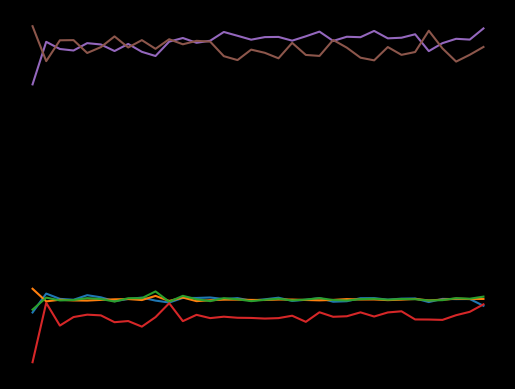

In [172]:
# 그래프 그리기
df_up_1.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [10]:
df_up_2 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(2)')
df_up_2

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.015882,0.046884,0.003971,-0.543484,5.545270,7.460632
1,-0.043371,0.001069,0.040012,-0.509965,6.349722,7.388806
2,0.042761,-0.060628,-0.137139,-0.727837,6.663363,7.197269
3,0.078802,0.066432,-0.045509,-0.371101,6.565200,7.032070
4,-0.062308,-0.005651,-0.029627,-0.464475,6.677728,7.345710
5,-0.036652,-0.034972,-0.016799,-0.260968,6.617873,7.381623
6,-0.016493,0.029169,0.068111,-0.495600,6.747159,6.613084
7,0.012828,0.029169,0.032681,-0.751779,6.771101,6.802226
8,-0.007941,-0.083841,-0.086437,-0.857124,6.656180,6.830957
9,-0.018326,0.016952,0.040012,-0.646434,6.821380,7.331345


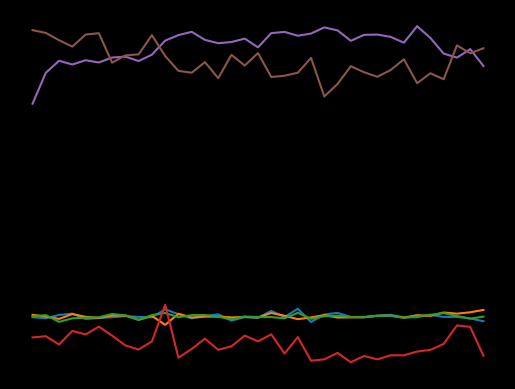

In [171]:
# 그래프 그리기
df_up_2.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [13]:
df_up_3 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(3)')
df_up_3

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.160658,-0.018479,-0.181732,-0.744597,6.148609,7.712023
1,0.063530,0.021228,0.022907,-0.409408,6.706458,6.771101
2,-0.060476,-0.016035,-0.002138,-0.239420,6.957850,7.202058
3,-0.019548,-0.053909,-0.034514,-0.174777,6.543653,7.120655
4,0.043371,-0.025198,0.007636,-0.210690,6.862082,6.941090
5,-0.014661,0.030391,0.038179,0.023942,6.876447,6.881235
6,0.009774,0.015730,0.020464,0.102951,6.818986,6.941090
7,0.015272,0.014508,-0.005192,-0.064643,6.962638,6.766313
8,-0.043982,0.003512,0.035125,0.184354,6.854899,7.096713
9,0.060476,-0.014203,-0.043677,-0.248997,6.627450,7.094319


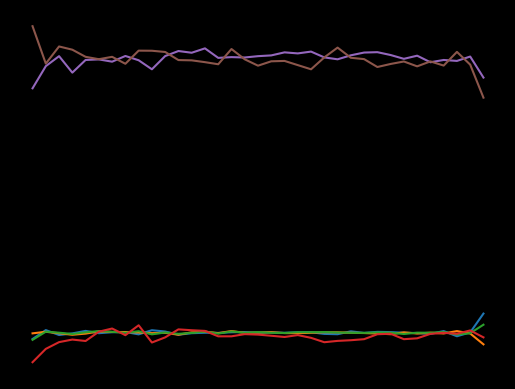

In [170]:
# 그래프 그리기
df_up_3.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [16]:
df_up_4 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(4)')
df_up_4

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.096517,-0.082620,-0.015577,-0.102951,6.340146,7.867646
1,-0.020159,0.005956,0.016188,-0.191536,6.534076,7.422325
2,0.003665,-0.027642,-0.014355,0.057461,6.598719,7.429507
3,-0.028100,0.039554,0.046731,-0.258574,6.471827,7.364864
4,0.029322,0.015730,-0.009468,-0.208296,6.718429,7.180510
5,-0.036652,-0.008094,-0.000916,-0.246603,6.689699,7.211635
6,-0.026878,0.037721,-0.003971,-0.165200,6.672939,7.446267
7,-0.033598,-0.029474,0.009468,0.028730,6.431125,7.532458
8,0.044593,0.013897,-0.013744,-0.011971,6.553229,7.360075
9,-0.070860,-0.085063,-0.003360,0.098162,6.488586,7.123049


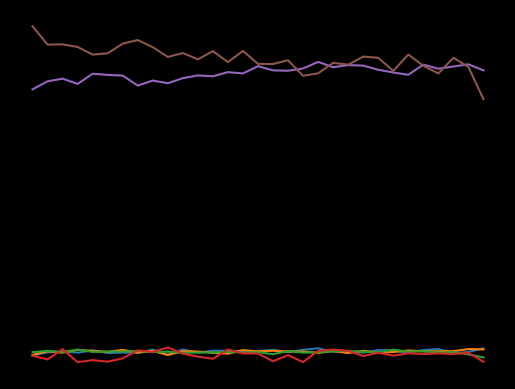

In [169]:
# 그래프 그리기
df_up_4.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [18]:
df_up_5 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(5)')
df_up_5

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.025656,0.031612,-0.025962,-0.849942,7.182904,6.423943
1,0.045815,-0.014813,-0.009468,-0.672771,7.316980,6.440702
2,-0.019548,-0.008705,-0.016188,-0.768539,7.407959,6.629844
3,0.031154,-0.005651,-0.004581,-0.682347,7.360075,6.378453
4,-0.037263,0.021838,0.003971,-0.548272,7.333739,6.529287
5,-0.026267,-0.003207,-0.003360,-0.612916,7.340922,6.603508
6,-0.009163,-0.005040,-0.008247,-0.629675,7.192481,6.687304
7,0.000611,0.000458,-0.002138,-0.636858,7.364864,6.447885
8,0.021380,-0.009316,-0.007636,-0.565032,7.283461,6.383241
9,0.006720,0.001069,0.000305,-0.541090,7.302615,6.395212


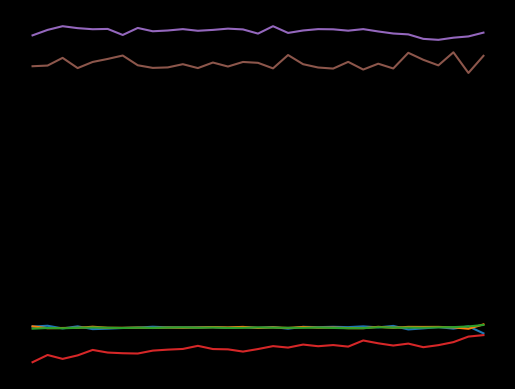

In [168]:
# 그래프 그리기
df_up_5.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [20]:
df_up_6 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(6)')
df_up_6

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.043371,0.087812,-0.010690,-0.270545,6.823774,6.938696
1,-0.036652,0.012065,-0.022297,-0.251391,6.797438,7.024887
2,-0.018937,0.003512,0.024740,-0.217872,6.732794,7.312191
3,-0.004887,-0.003207,0.019853,-0.356736,6.720823,7.099107
4,-0.018326,0.005956,-0.004581,-0.349553,6.701670,7.156568
5,0.003665,0.018784,-0.015577,-0.541090,6.728006,7.125443
6,0.031765,0.001680,0.013134,-0.490811,6.723217,7.056012
7,0.035430,0.040164,-0.000916,-0.545878,6.718429,7.034464
8,-0.041539,-0.023366,-0.018631,-0.588974,6.648997,7.369652
9,0.042761,0.011454,-0.008858,-0.608127,6.601113,7.056012


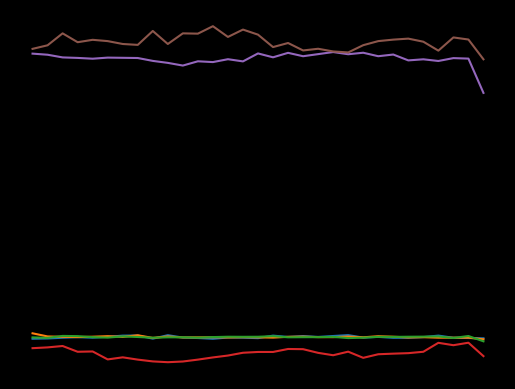

In [167]:
# 그래프 그리기
df_up_6.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [22]:
df_up_7 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(7)')
df_up_7

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.050091,0.107970,0.063835,-0.095768,6.593931,7.202058
1,-0.023213,0.038332,0.037568,-0.481235,6.730400,6.941090
2,-0.034208,0.027947,-0.025962,-0.383072,6.809409,7.295432
3,0.025045,0.021838,0.012523,-0.368707,6.811803,7.254730
4,-0.032987,-0.012981,-0.027794,-0.263362,6.809409,7.168539
5,-0.021991,-0.000764,-0.011301,-0.301669,6.704064,7.173327
6,-0.018937,0.024893,0.011912,-0.442927,6.680122,7.221211
7,-0.017104,-0.004429,-0.014966,-0.442927,6.569989,7.247548
8,-0.026878,-0.061239,0.006414,-0.442927,6.625055,7.082348
9,-0.078191,-0.019700,0.000916,-0.555455,6.522105,7.489362


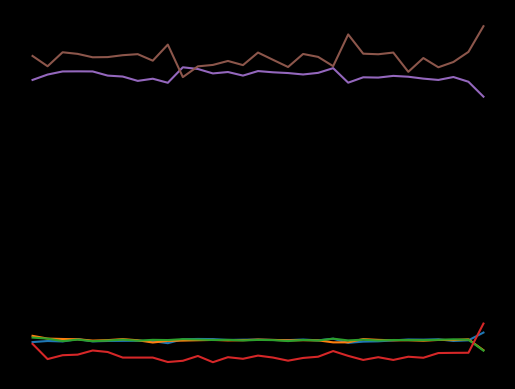

In [166]:
# 그래프 그리기
df_up_7.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [24]:
df_up_8 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(8)')
df_up_8

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.004887,0.066432,-0.088881,-0.208296,6.246771,7.293037
1,0.028711,0.046884,0.008858,-0.198719,6.450279,7.269095
2,0.012828,0.005345,-0.035125,-0.560243,6.629844,7.436690
3,-0.018937,-0.031307,-0.005192,-0.519542,6.433519,7.364864
4,0.012217,-0.005651,0.005803,-0.560243,6.584354,7.111078
5,-0.071471,0.001069,-0.010690,-0.438139,6.464644,7.515698
6,-0.005498,0.018173,0.015577,-0.560243,6.390424,7.376835
7,-0.044593,-0.021533,-0.003360,-0.481235,6.354511,7.472603
8,0.029932,0.004123,0.010079,-0.584185,6.498163,7.185298
9,0.047037,-0.013592,0.011301,-0.557849,6.419154,7.137414


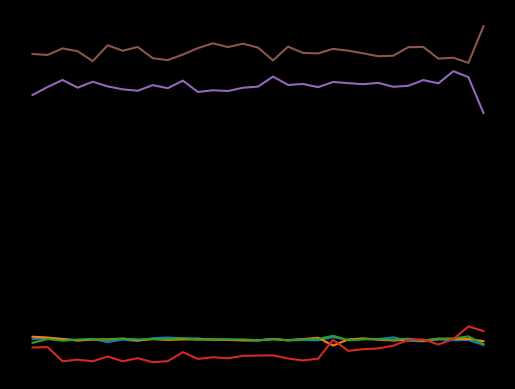

In [165]:
# 그래프 그리기
df_up_8.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [26]:
df_up_9 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(9)')
df_up_9

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.120951,-0.023976,-0.036957,-0.196325,6.852505,7.333739
1,-0.035430,-0.000764,0.004581,-0.373495,6.004957,7.558794
2,0.014050,0.019395,-0.031460,-0.435745,6.459856,7.470209
3,-0.013439,-0.041692,0.019242,-0.246603,6.320992,7.453449
4,0.012217,-0.032529,-0.040012,-0.162806,6.467038,7.180510
5,-0.028100,-0.023366,-0.036957,0.079009,6.385635,7.419930
6,0.043982,-0.008705,-0.036346,-0.191536,6.428731,7.381623
7,-0.028100,0.031001,0.002749,-0.397437,6.433519,7.439084
8,-0.004276,-0.019090,-0.041233,-0.593762,6.464644,7.439084
9,-0.040317,-0.002596,0.032681,-0.342371,6.356905,7.513304


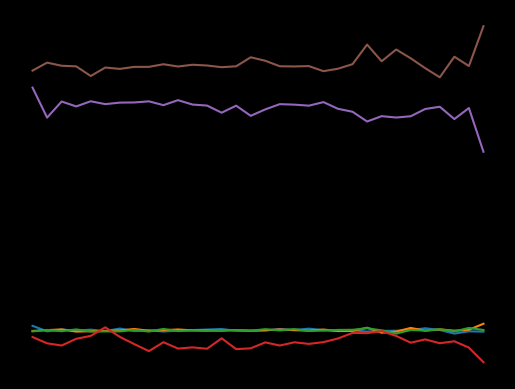

In [164]:
# 그래프 그리기
df_up_9.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [28]:
df_up_10 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(10)')
df_up_10

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.762971,-0.054520,0.190895,0.002394,5.650615,8.032846
1,-0.009774,0.021838,0.086437,-0.074220,5.961862,7.671321
2,0.011606,0.034667,-0.037568,0.016759,6.558018,7.551611
3,0.020159,-0.015424,0.016799,0.047884,6.198887,7.740753
4,-0.023824,0.020617,-0.049786,0.162806,6.241983,7.546823
5,0.091630,0.051160,-0.019853,0.026336,6.467038,7.302615
6,-0.031154,0.056047,0.039401,0.229843,6.383241,7.412748
7,0.017104,-0.045357,-0.036346,0.265756,6.400001,7.319374
8,0.020769,-0.028863,-0.044288,0.270545,6.320992,7.561188
9,-0.000611,-0.013592,0.007636,0.356736,6.273108,7.604284


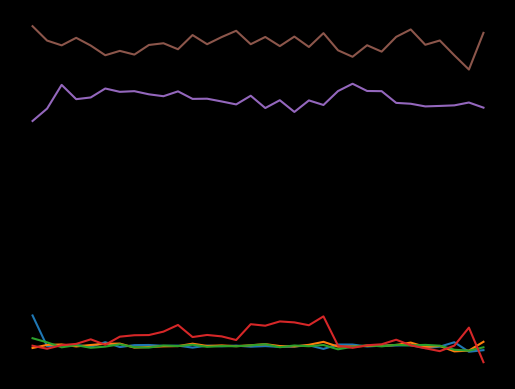

In [163]:
# 그래프 그리기
df_up_10.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [30]:
df_up_11 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(11)')
df_up_11

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.021991,0.189216,-0.048564,-0.720655,5.988198,7.692869
1,0.007941,-0.018479,0.045509,-0.241814,6.299444,7.635408
2,0.056810,-0.076511,0.044288,-0.361524,6.536470,7.285855
3,0.056810,-0.042302,-0.070555,-0.153229,6.172551,7.367258
4,-0.020769,-0.033139,-0.041844,-0.294487,6.201282,7.886800
5,0.000000,0.002291,-0.038790,-0.390255,6.409577,7.484574
6,-0.004276,0.016952,0.033903,-0.174777,6.198887,7.494151
7,0.018326,-0.003207,0.013134,-0.086191,6.151003,7.640197
8,-0.009774,-0.011148,0.025962,-0.179565,6.323386,7.625832
9,-0.011606,0.004734,0.007025,0.023942,6.117485,7.592313


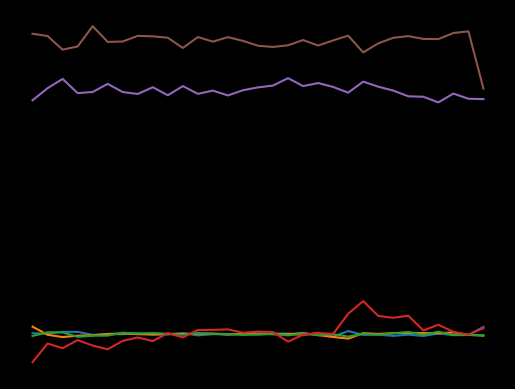

In [162]:
# 그래프 그리기
df_up_11.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [32]:
df_up_12 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(12)')
df_up_12

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.210749,-0.081398,-0.095600,-0.234632,6.376059,7.319374
1,0.072082,-0.037415,0.086437,0.064643,6.471827,7.044041
2,0.042761,0.023671,-0.030849,-0.227449,6.708852,7.415142
3,-0.086743,0.120799,0.071166,0.402226,6.390424,7.549217
4,-0.004887,-0.012370,-0.036346,-0.371101,6.155792,7.709629
5,-0.005498,-0.010537,0.034514,0.062249,6.158186,7.609072
6,-0.038485,0.005345,0.019853,0.043096,6.009746,7.898771
7,0.040317,-0.003818,-0.053451,-0.055067,6.445490,7.554006
8,0.049480,0.001069,-0.018021,-0.150835,6.380847,7.364864
9,0.011606,-0.003207,-0.033903,-0.193930,6.464644,7.489362


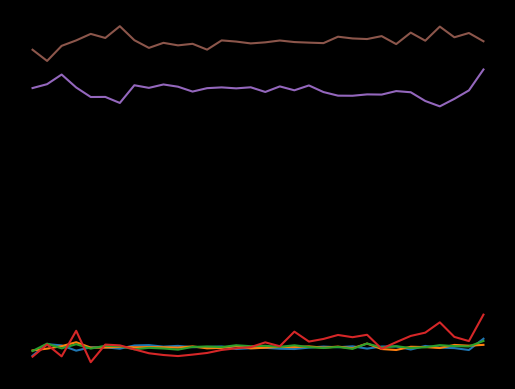

In [161]:
# 그래프 그리기
df_up_12.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [34]:
df_up_13 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(13)')
df_up_13

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.054978,-0.021533,-0.021686,0.052672,6.507740,7.142203
1,0.013439,0.131183,0.134085,0.191536,6.986580,7.290643
2,-0.009163,-0.050244,-0.077274,-0.138864,6.914754,7.309797
3,0.078191,0.024893,-0.000305,-0.179565,6.586748,7.283461
4,0.005498,-0.011148,-0.023518,-0.205901,6.828563,7.000945
5,0.004887,-0.001985,-0.002749,-0.136469,6.708852,7.070377
6,-0.019548,-0.003207,0.005803,-0.172383,6.723217,7.242759
7,-0.041539,0.015119,0.019242,-0.110133,6.768707,7.190087
8,0.025045,-0.006872,-0.024129,-0.292093,6.857293,6.933908
9,-0.006109,0.006567,-0.027184,-0.158017,6.778284,7.111078


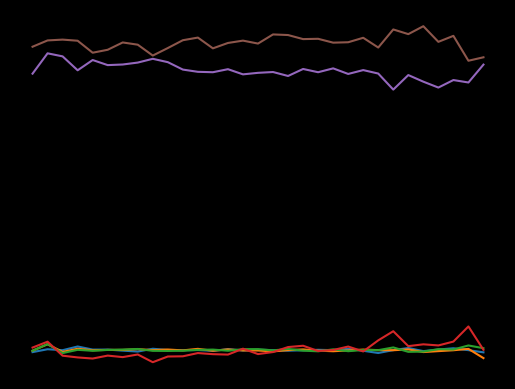

In [160]:
# 그래프 그리기
df_up_13.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [36]:
df_up_14 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(14)')
df_up_14

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.029322,-0.306196,-0.047342,-0.296881,7.771878,7.400777
1,-0.164934,0.054825,0.060781,-0.624887,6.921937,7.419930
2,0.011606,-0.009927,0.022297,-0.284910,7.032070,6.845322
3,-0.031765,0.006567,-0.002138,-0.090980,7.297826,6.474221
4,-0.014661,0.020006,0.003971,-0.265756,7.056012,6.792649
5,-0.042761,0.035277,-0.017410,-0.275333,7.211635,6.799832
6,0.020159,-0.015424,-0.006414,-0.239420,7.060800,6.704064
7,0.041539,0.048106,-0.031460,-0.272939,6.888418,6.914754
8,-0.071471,0.160505,0.007025,-0.373495,6.871658,6.821380
9,0.006720,0.087812,0.051007,-0.026336,6.883629,6.974609


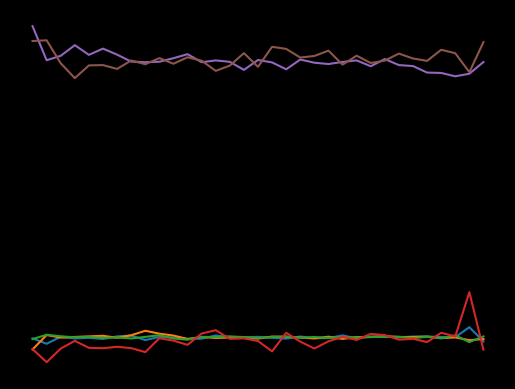

In [159]:
# 그래프 그리기
df_up_14.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [38]:
df_up_15 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(15)')
df_up_15

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.025656,0.208152,0.439518,-0.237026,5.710470,8.119038
1,0.002443,-0.082620,0.008247,0.251391,6.079177,7.769484
2,-0.079412,0.046273,-0.114537,0.083797,6.060024,8.475773
3,0.108123,-0.016646,-0.020464,0.033519,6.368876,7.285855
4,0.007330,-0.003818,-0.030238,-0.100556,6.493374,7.506122
5,0.052534,0.004734,-0.000305,-0.179565,6.558018,7.252336
6,-0.010996,0.016341,0.029016,-0.217872,6.680122,7.218817
7,0.000000,-0.009927,-0.010690,-0.043096,6.414366,7.309797
8,0.000000,0.016952,0.008858,-0.289698,6.637026,7.367258
9,-0.061087,-0.012370,0.063225,0.026336,6.280290,7.527669


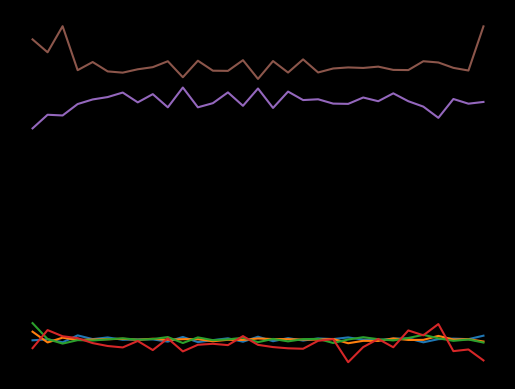

In [158]:
# 그래프 그리기
df_up_15.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [40]:
df_up_16 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(16)')
df_up_16

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.177151,0.122631,0.276417,-0.988805,6.447885,8.111855
1,-0.155160,0.133016,-0.002138,-0.610521,6.605902,7.618649
2,0.007941,0.001069,0.069333,-0.040701,6.708852,7.218817
3,0.006109,0.010843,-0.074220,-0.378284,6.447885,7.594707
4,-0.027489,0.026725,0.031460,-0.225055,6.380847,7.395988
5,0.026267,0.022449,-0.012523,-0.615310,6.443096,7.312191
6,0.011606,0.001680,-0.014355,-0.756568,6.416760,7.321768
7,0.027489,-0.022144,0.013744,-0.567426,6.502951,7.170933
8,0.007330,-0.010537,0.002749,-0.617704,6.495769,7.331345
9,0.000000,0.014508,-0.003360,-0.526724,6.316204,7.410354


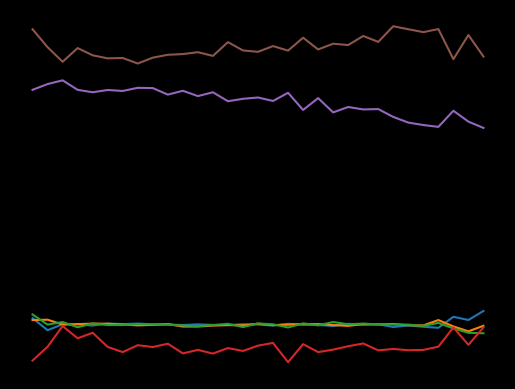

In [157]:
# 그래프 그리기
df_up_16.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [42]:
df_up_17 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(17)')
df_up_17

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.250455,-0.121715,-0.128587,-0.476446,6.419154,7.546823
1,-0.166155,0.102473,0.000916,-0.098162,6.452673,8.054394
2,0.058032,0.043830,-0.008858,-0.007183,7.340922,6.711246
3,-0.048869,-0.020922,0.021075,-0.088585,6.950667,6.953061
4,-0.095295,0.074984,-0.038179,-0.502782,6.682516,7.295432
5,0.005498,0.024282,0.054672,-0.529119,6.596325,7.060800
6,-0.071471,0.096364,-0.011301,-0.663194,6.483798,7.412748
7,-0.010385,-0.016035,-0.047953,-0.497994,6.610690,7.312191
8,0.036041,-0.003207,0.053451,-0.270545,6.763919,7.091925
9,-0.011606,0.010232,-0.013134,-0.378284,6.603508,7.357681


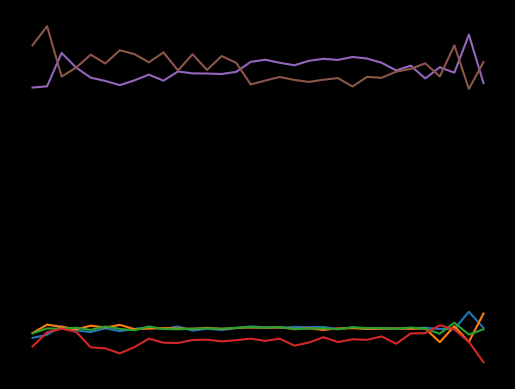

In [156]:
# 그래프 그리기
df_up_17.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [44]:
df_up_18 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(18)')
df_up_18

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.232740,-0.129656,0.236710,-0.177171,7.501333,7.542035
1,-0.013439,-0.101556,-0.057727,-0.375890,6.565200,6.881235
2,0.041539,-0.012370,0.076664,-0.033519,6.917148,6.689699
3,0.147829,-0.060018,0.090103,0.079009,6.704064,7.218817
4,-0.044593,-0.075900,0.004581,-0.117316,6.883629,7.194875
5,-0.028711,-0.039859,-0.048564,-0.481235,6.548441,7.293037
6,0.000611,0.026114,-0.018021,-0.586579,6.435914,7.242759
7,0.000611,0.001069,0.010079,-0.545878,6.414366,7.422325
8,-0.013439,-0.009927,-0.038179,-0.490811,6.514922,7.376835
9,-0.014661,0.025504,0.030238,-0.265756,6.706458,7.115867


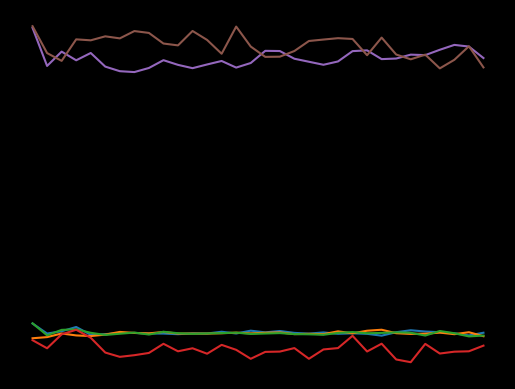

In [155]:
# 그래프 그리기
df_up_18.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [46]:
df_up_19 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(19)')
df_up_19

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,-0.097738,0.291230,0.360105,-0.720655,5.052065,8.892365
1,-0.072082,0.035888,-0.021686,-0.814029,6.143821,7.755118
2,-0.074526,-0.078343,0.026573,-0.497994,6.091148,7.841310
3,-0.056200,0.004734,-0.005192,-0.531513,5.815815,7.872435
4,-0.007941,0.035277,0.004581,-0.581791,6.031293,7.554006
5,-0.004887,0.007178,-0.018021,-0.577003,5.930737,7.860464
6,-0.010996,0.052382,0.016188,-0.725443,5.952285,7.834127
7,-0.061087,0.024282,0.014966,-0.641646,5.892430,8.157345
8,-0.048869,0.012065,0.005803,-0.787692,5.887641,7.850887
9,-0.017104,0.033445,0.015577,-0.811634,5.918766,7.779060


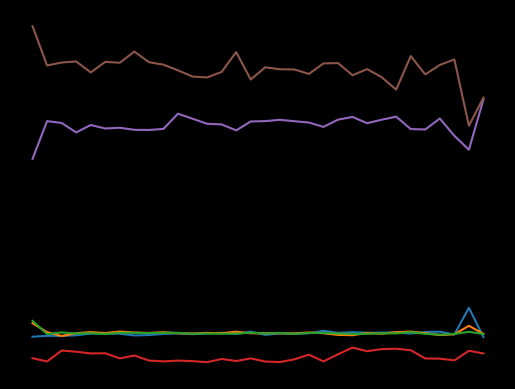

In [154]:
# 그래프 그리기
df_up_19.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [48]:
df_up_20 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(20)')
df_up_20

,gyro X,gyro Y,gyro Z,accel X,accel Y,accel Z
0,0.120951,-0.034972,0.184176,-0.675165,4.865018,7.874829
1,0.182038,-0.009927,0.122478,-0.751779,6.471827,7.084742
2,0.007941,0.020006,-0.023518,-0.359130,6.859687,6.929119
3,0.034208,0.040775,0.003971,-0.636858,6.668151,6.687304
4,0.003054,0.032223,0.047342,-0.536301,6.864476,6.902783
5,-0.089797,-0.033139,-0.052229,-0.636858,6.517316,7.611466
6,0.077580,-0.057574,0.070555,-0.512359,6.919542,6.893206
7,0.017715,0.018784,-0.077885,-0.428562,6.783072,6.914754
8,0.029322,0.005345,-0.027184,-0.687136,6.941090,7.058406
9,0.003665,-0.047189,-0.004581,-0.756568,6.862082,6.945879


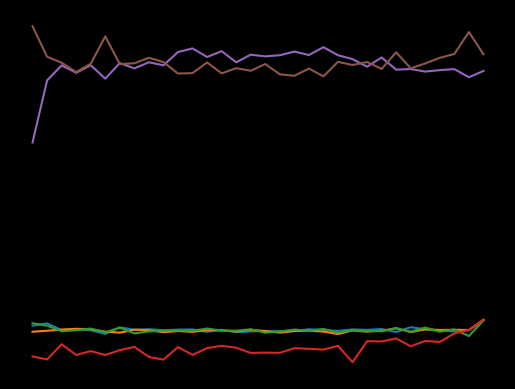

In [153]:
# 그래프 그리기
df_up_20.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

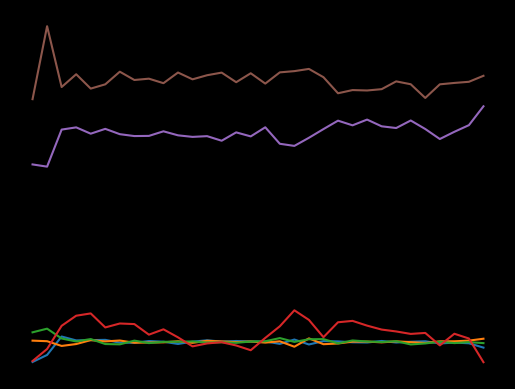

In [152]:
df_up_21 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(21)')
# 그래프 그리기
df_up_21.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

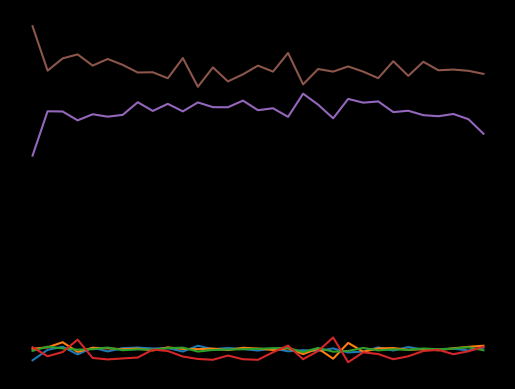

In [151]:
df_up_22 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(22)')
# 그래프 그리기
df_up_22.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

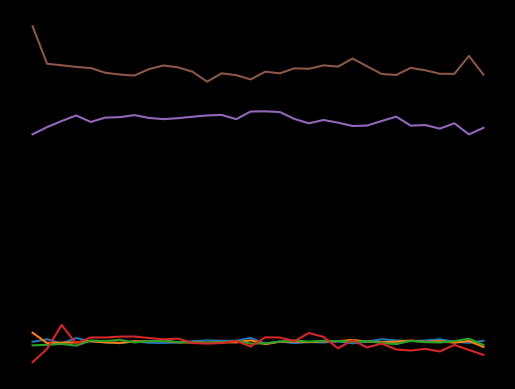

In [150]:
df_up_23 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(23)')
# 그래프 그리기
df_up_23.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

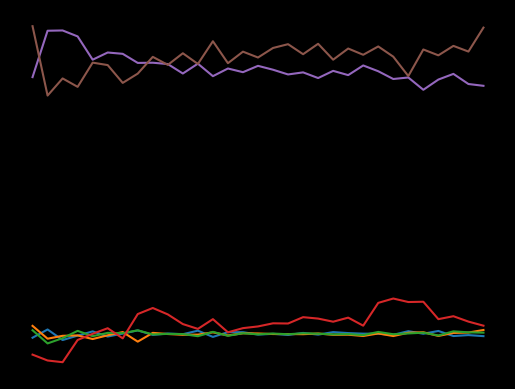

In [149]:
df_up_24 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to 2 up(24)')
# 그래프 그리기
df_up_24.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

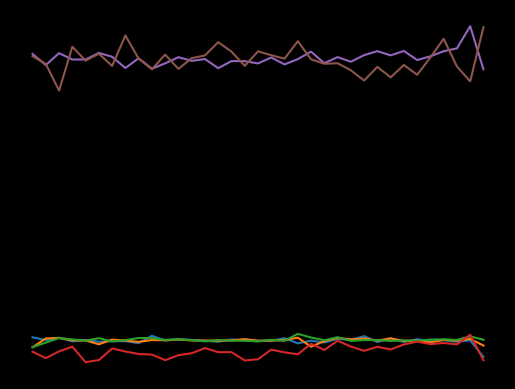

In [148]:
df_down_1 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(1)')
# 그래프 그리기
df_down_1.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

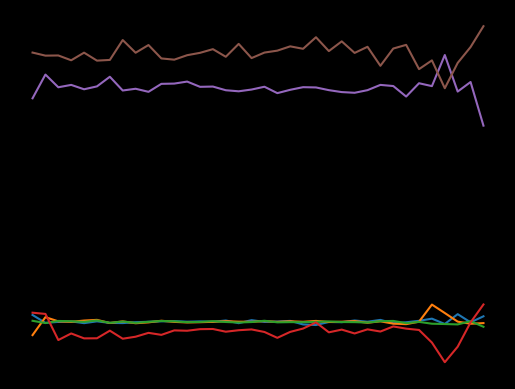

In [147]:
df_down_2 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(2)')
# 그래프 그리기
df_down_2.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

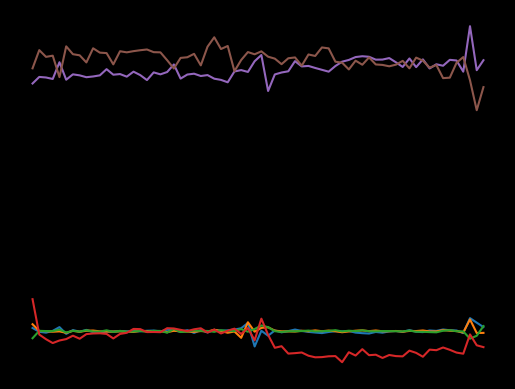

In [146]:
df_down_3 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(3)')
# 그래프 그리기
df_down_3.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

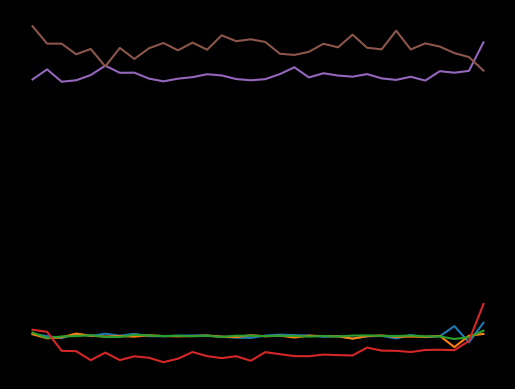

In [145]:
df_down_4 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(4)')
# 그래프 그리기
df_down_4.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

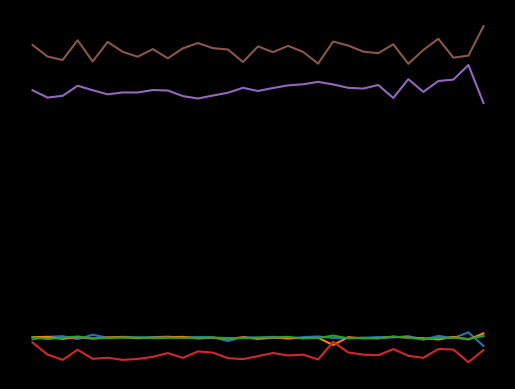

In [144]:
df_down_5 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(5)')
# 그래프 그리기
df_down_5.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

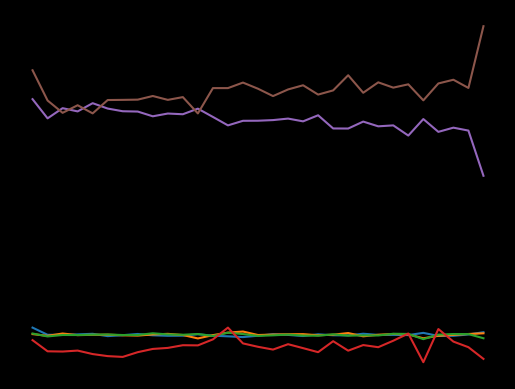

In [143]:
df_down_6 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(6)')
# 그래프 그리기
df_down_6.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

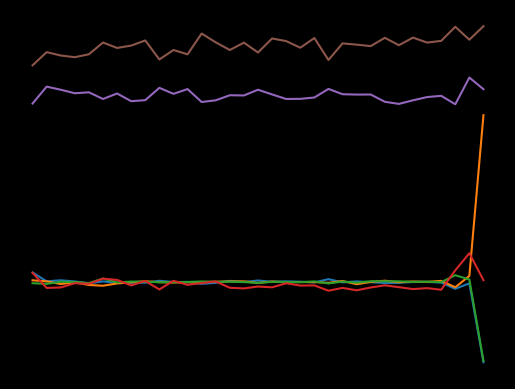

In [142]:
df_down_7 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(7)')
# 그래프 그리기
df_down_7.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

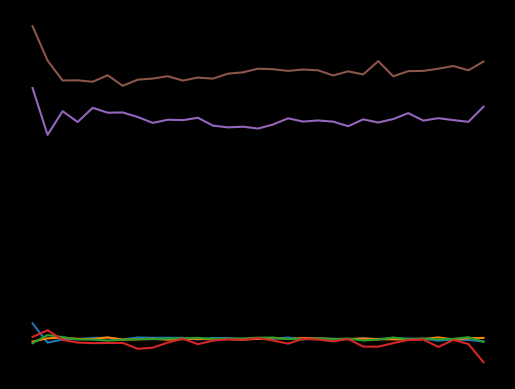

In [141]:
df_down_8 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(8)')
# 그래프 그리기
df_down_8.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

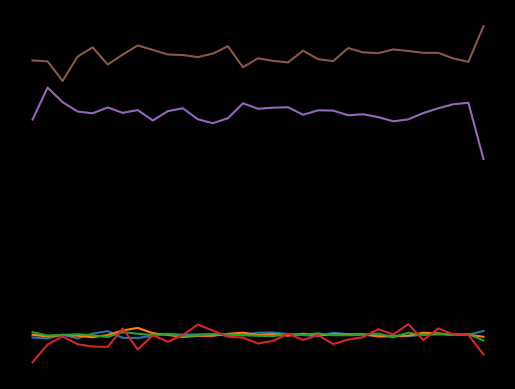

In [140]:
df_down_9 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(9)')
# 그래프 그리기
df_down_9.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

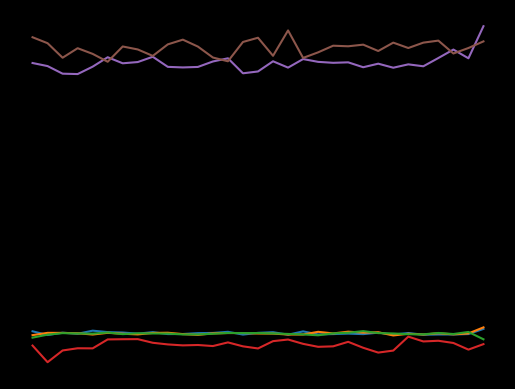

In [139]:
df_down_10 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(10)')
# 그래프 그리기
df_down_10.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

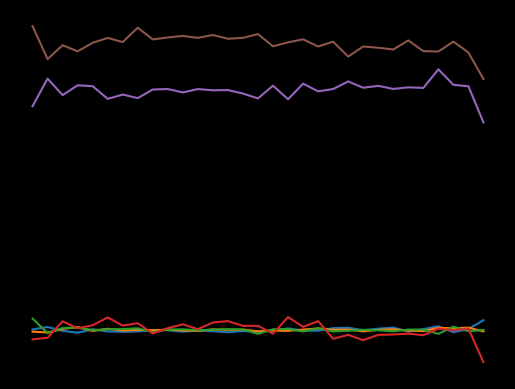

In [138]:
df_down_11 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(11)')
# 그래프 그리기
df_down_11.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

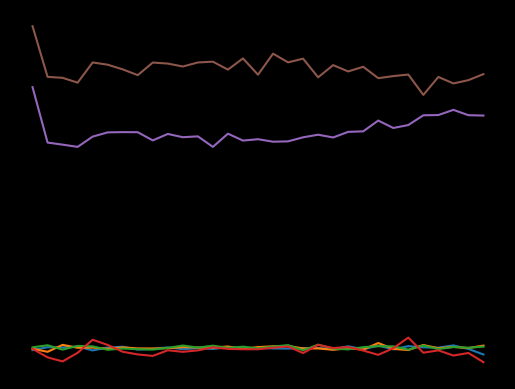

In [137]:
df_down_12 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(12)')
# 그래프 그리기
df_down_12.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

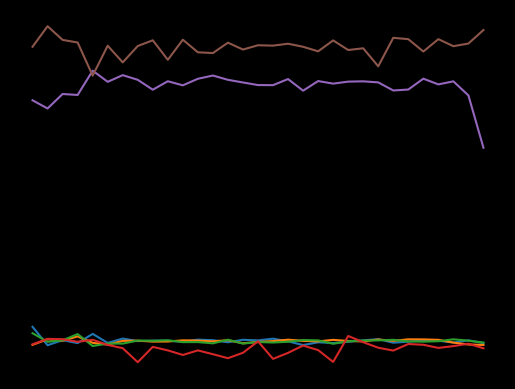

In [136]:
df_down_13 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(13)')
# 그래프 그리기
df_down_13.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

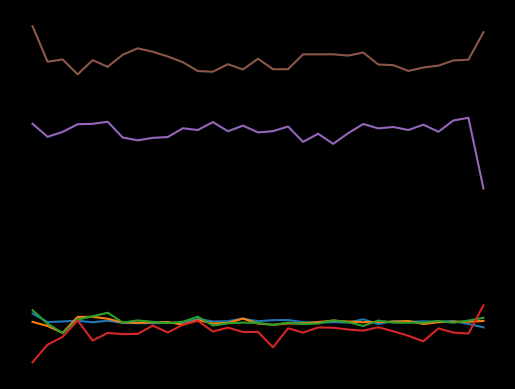

In [135]:
df_down_14 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(14)')
# 그래프 그리기
df_down_14.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

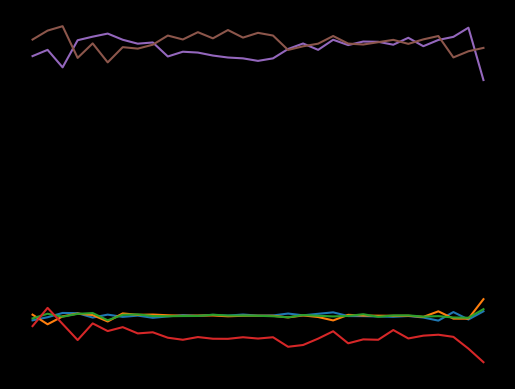

In [134]:
df_down_15 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(15)')
# 그래프 그리기
df_down_15.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

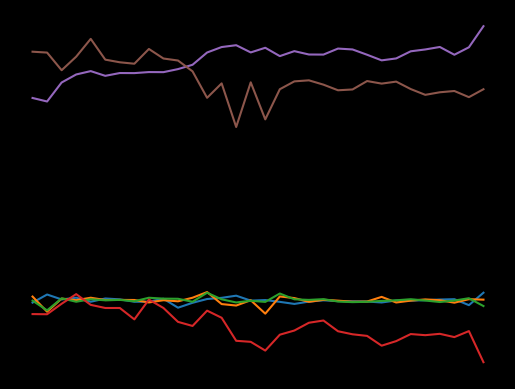

In [133]:
df_down_16 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(16)')
# 그래프 그리기
df_down_16.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

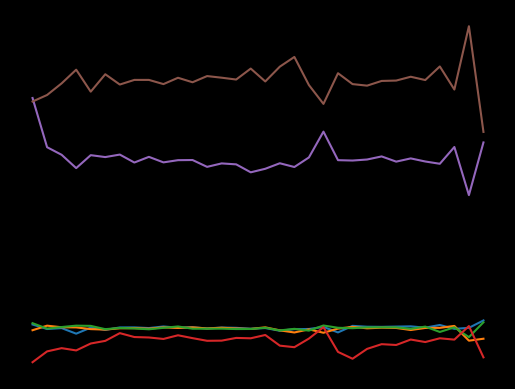

In [132]:
df_down_17 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(17)')
# 그래프 그리기
df_down_17.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

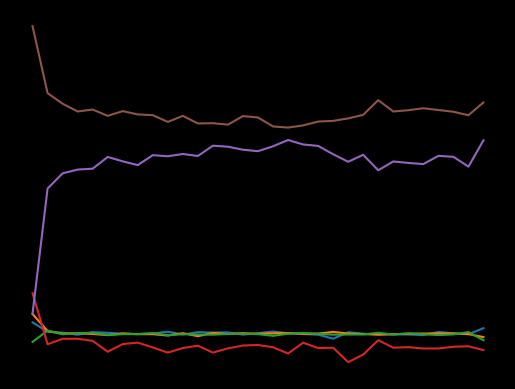

In [131]:
df_down_18 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(18)')
# 그래프 그리기
df_down_18.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

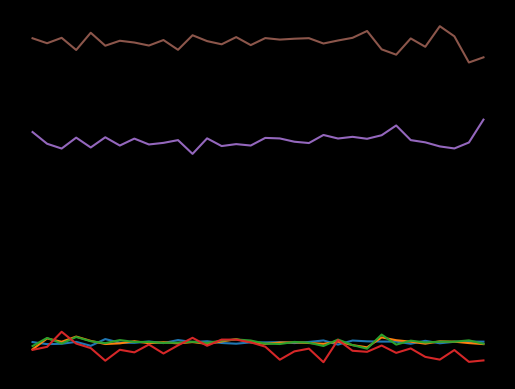

In [130]:
df_down_19 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(19)')
# 그래프 그리기
df_down_19.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

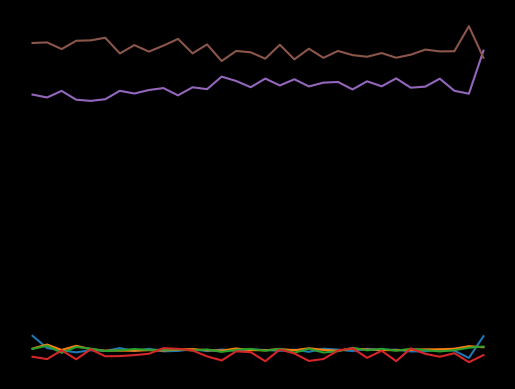

In [129]:
df_down_20 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(20)')
# 그래프 그리기
df_down_20.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

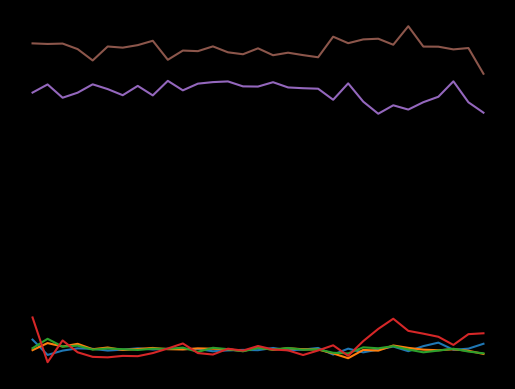

In [128]:
df_down_21 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(21)')
# 그래프 그리기
df_down_21.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

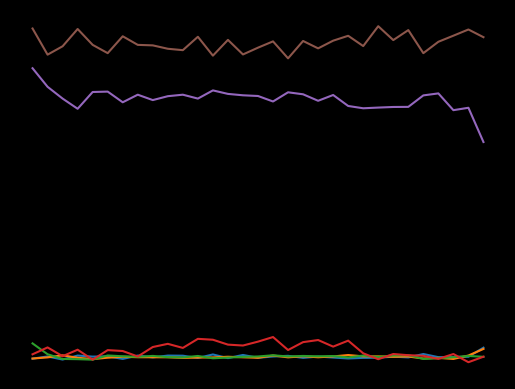

In [127]:
df_down_22 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(22)')
# 그래프 그리기
df_down_22.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

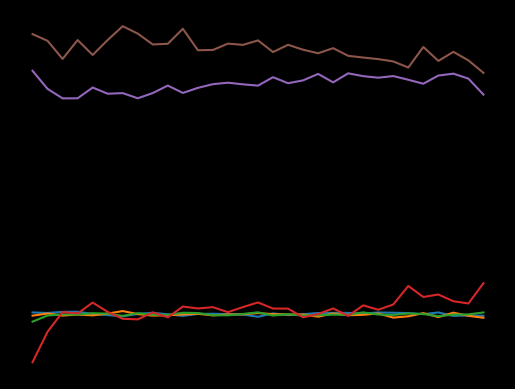

In [126]:
df_down_23 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 1 down(23)')
# 그래프 그리기
df_down_23.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

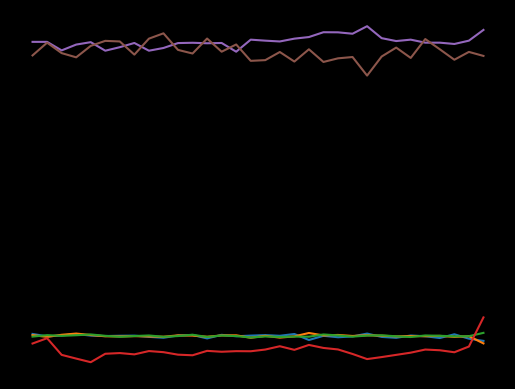

In [121]:
df_up_25 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(1)')
# 그래프 그리기
df_up_25.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

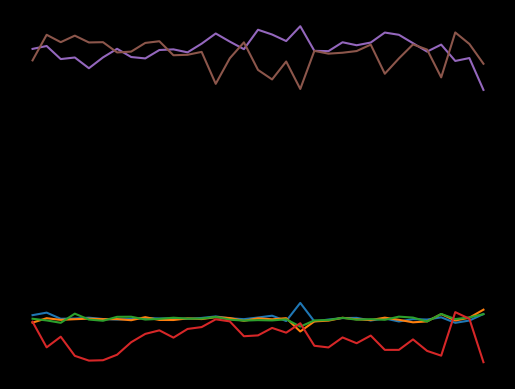

In [120]:
df_up_26 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(2)')
# 그래프 그리기
df_up_26.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

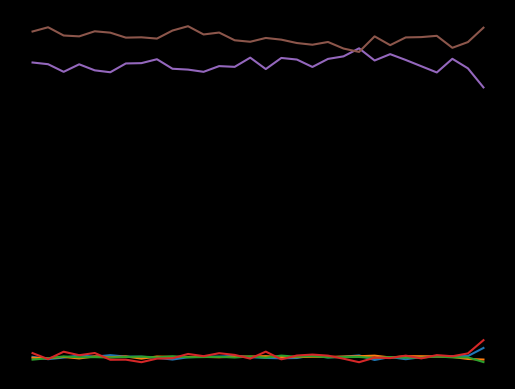

In [119]:
df_up_27 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(3)')

# 그래프 그리기
df_up_27.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

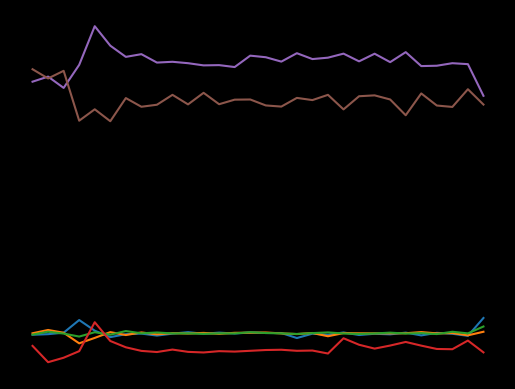

In [174]:
df_up_28 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(4)')

# 그래프 그리기
df_up_28.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

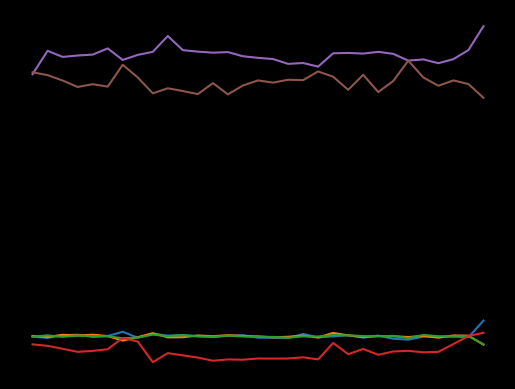

In [175]:
df_up_29 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(5)')

# 그래프 그리기
df_up_29.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

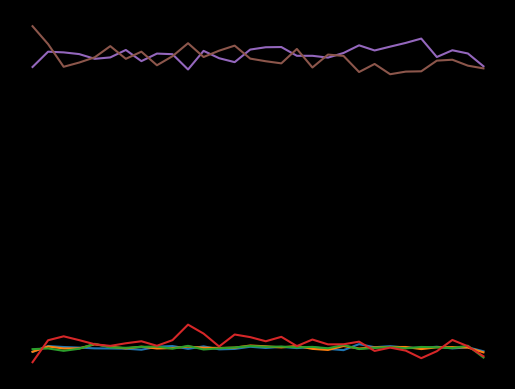

In [177]:
df_up_30 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(6)')

# 그래프 그리기
df_up_30.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

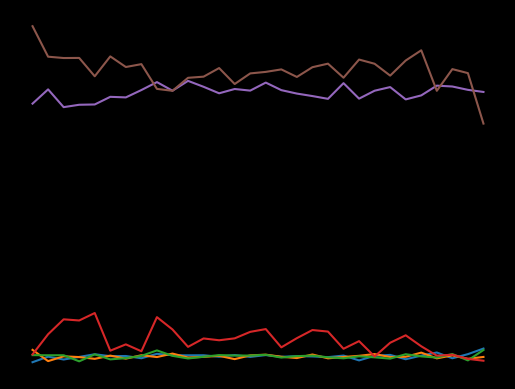

In [179]:
df_up_31 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(7)')

# 그래프 그리기
df_up_31.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

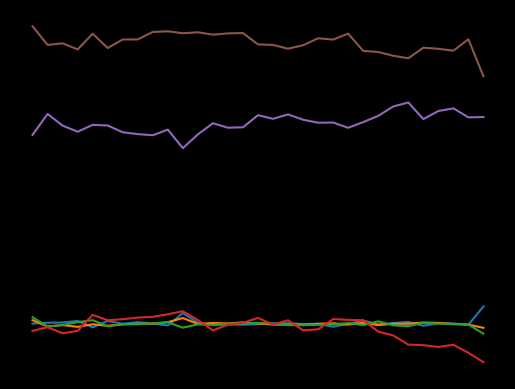

In [180]:
df_up_32 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='2 to 3 up(8)')

# 그래프 그리기
df_up_32.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

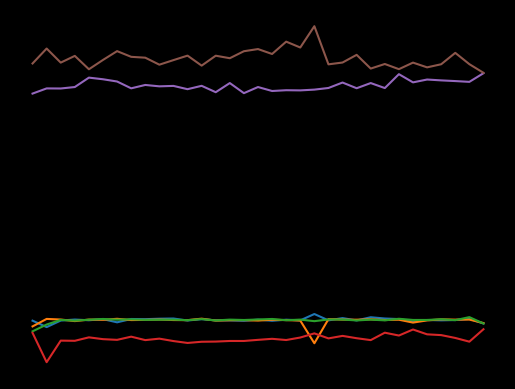

In [191]:
df_down_24 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(1)')

# 그래프 그리기
df_down_24.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

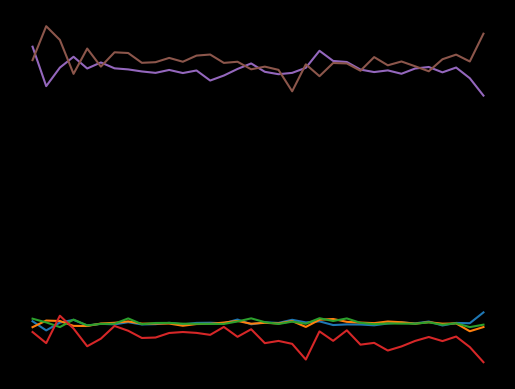

In [192]:
df_down_25 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(2)')

# 그래프 그리기
df_down_25.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

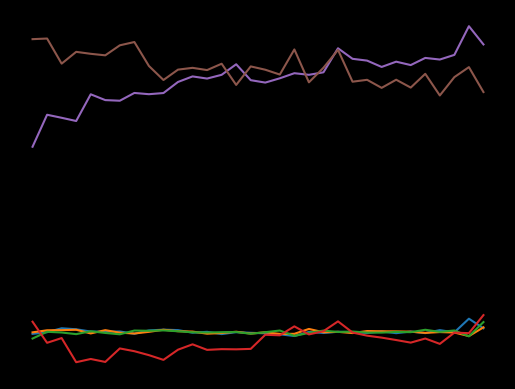

In [193]:
df_down_26 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(3)')

# 그래프 그리기
df_down_26.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

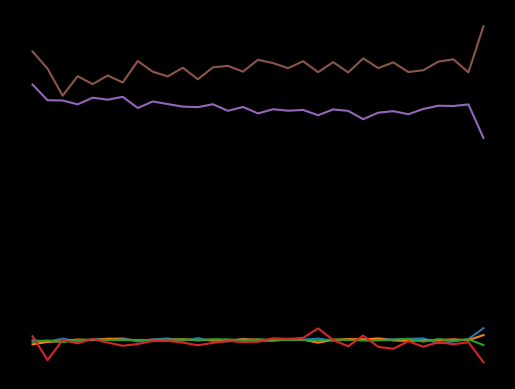

In [194]:
df_down_27 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(4)')

# 그래프 그리기
df_down_27.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

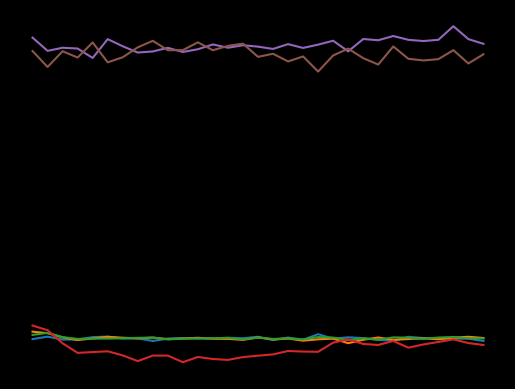

In [195]:
df_down_28 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(5)')

# 그래프 그리기
df_down_28.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

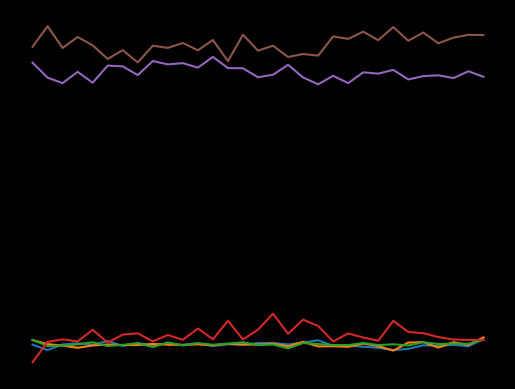

In [196]:
df_down_29 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(6)')

# 그래프 그리기
df_down_29.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

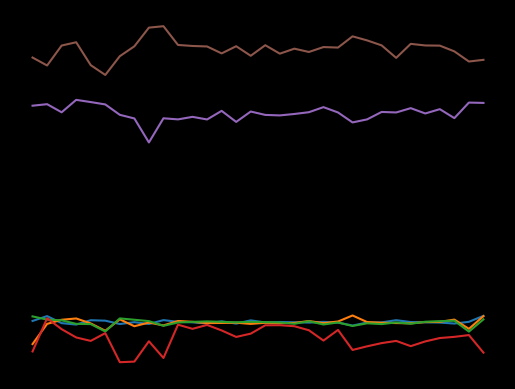

In [197]:
df_down_30 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(7)')

# 그래프 그리기
df_down_30.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

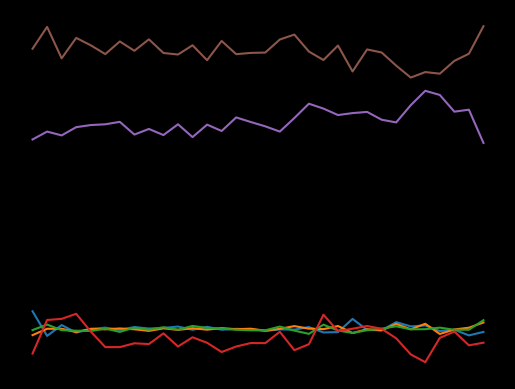

In [198]:
df_down_31 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='3 to 2 down(8)')

# 그래프 그리기
df_down_31.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

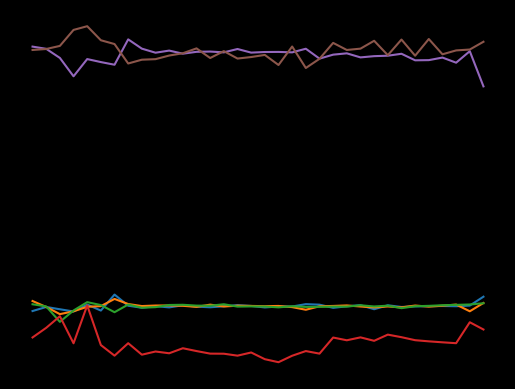

In [199]:
df_up_33 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(1)')

# 그래프 그리기
df_up_33.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

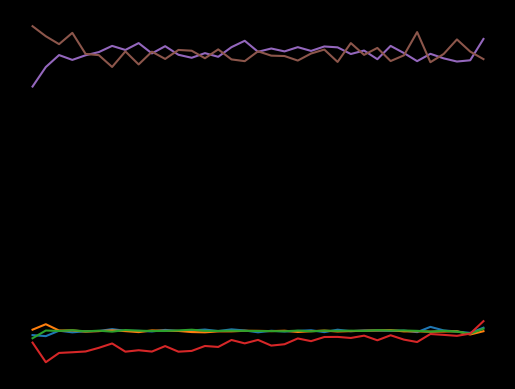

In [200]:
df_up_34 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(2)')

# 그래프 그리기
df_up_34.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

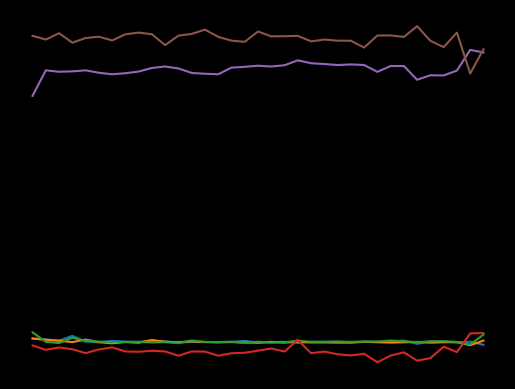

In [201]:
df_up_35 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(3)')

# 그래프 그리기
df_up_35.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

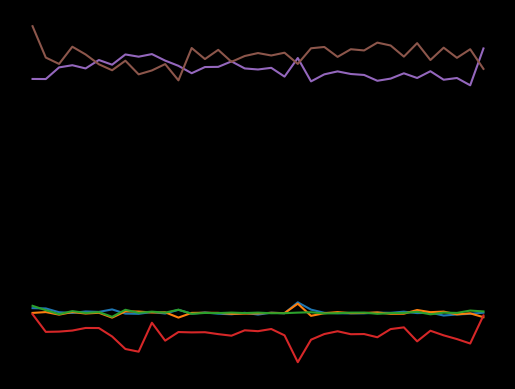

In [203]:
df_up_36 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(4)')

# 그래프 그리기
df_up_36.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

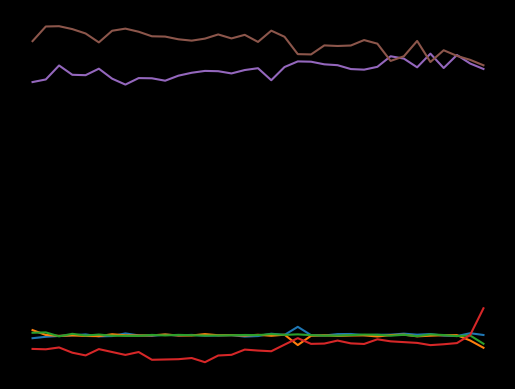

In [204]:
df_up_37 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(5)')

# 그래프 그리기
df_up_37.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

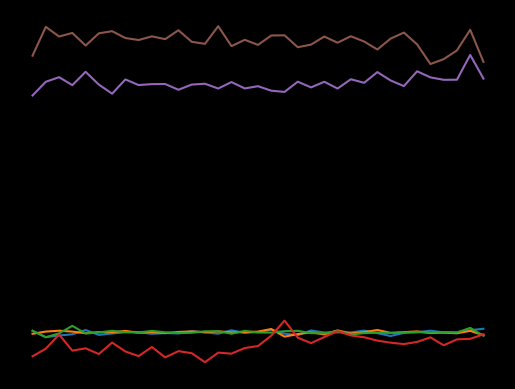

In [205]:
df_up_38 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(6)')

# 그래프 그리기
df_up_38.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

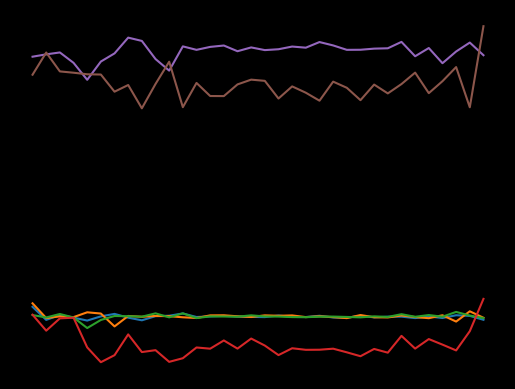

In [206]:
df_up_39 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(7)')

# 그래프 그리기
df_up_39.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

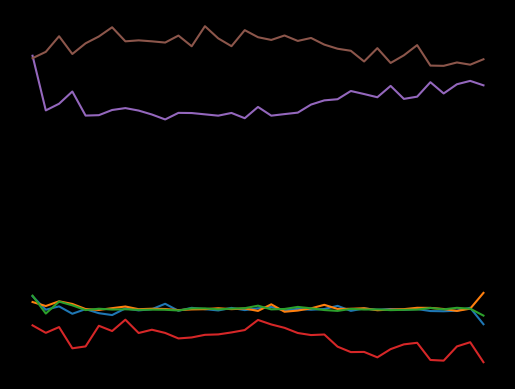

In [207]:
df_up_40 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(8)')

# 그래프 그리기
df_up_40.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

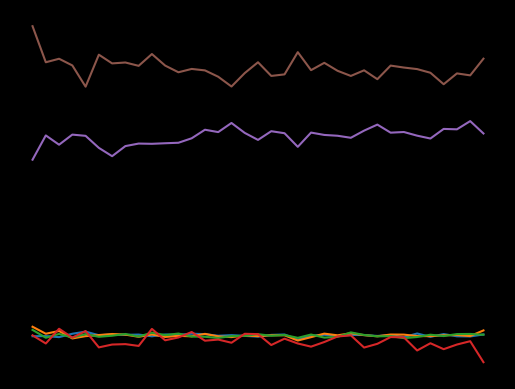

In [208]:
df_up_41 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(9)')

# 그래프 그리기
df_up_41.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

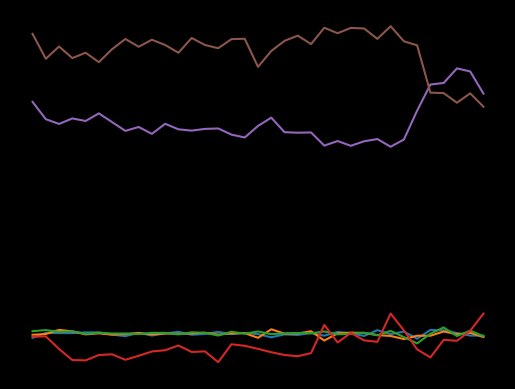

In [209]:
df_up_42 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(10)')

# 그래프 그리기
df_up_42.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

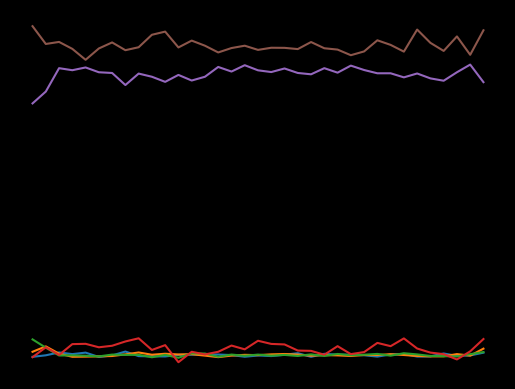

In [210]:
df_up_43 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='b1 to 1 up(11)')

# 그래프 그리기
df_up_43.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

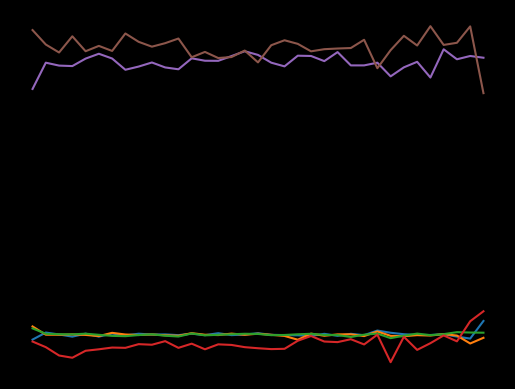

In [212]:
df_down_32 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(1)')

# 그래프 그리기
df_down_32.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

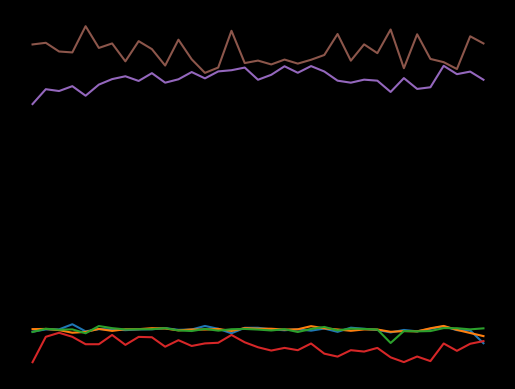

In [213]:
df_down_33 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(2)')

# 그래프 그리기
df_down_33.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

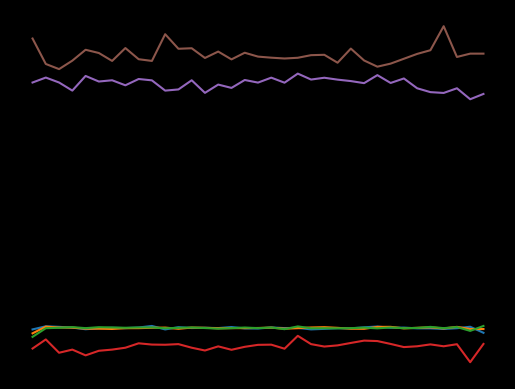

In [214]:
df_down_34 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(3)')

# 그래프 그리기
df_down_34.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

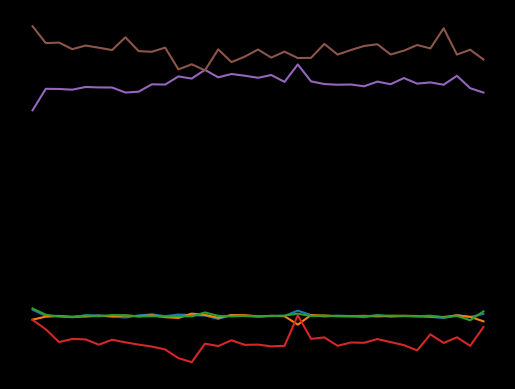

In [215]:
df_down_35 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(4)')

# 그래프 그리기
df_down_35.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

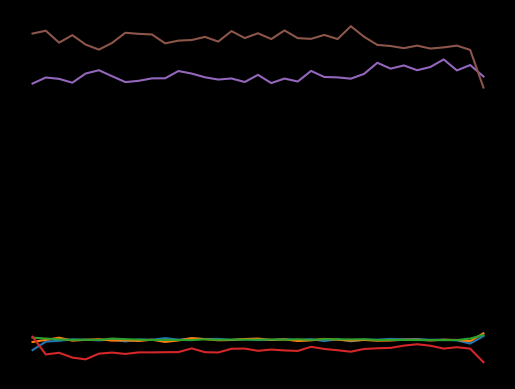

In [216]:
df_down_36 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(5)')

# 그래프 그리기
df_down_36.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

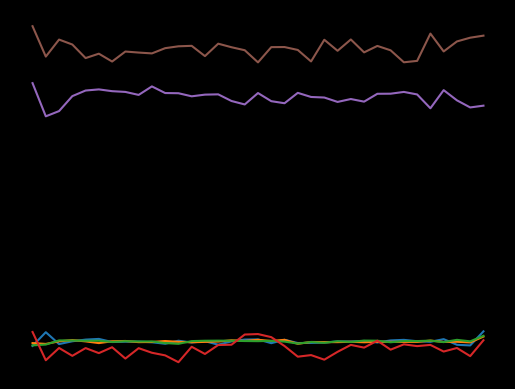

In [217]:
df_down_37 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(6)')

# 그래프 그리기
df_down_37.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

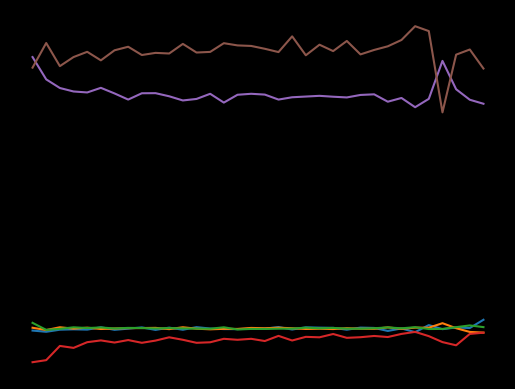

In [218]:
df_down_38 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(7)')

# 그래프 그리기
df_down_38.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

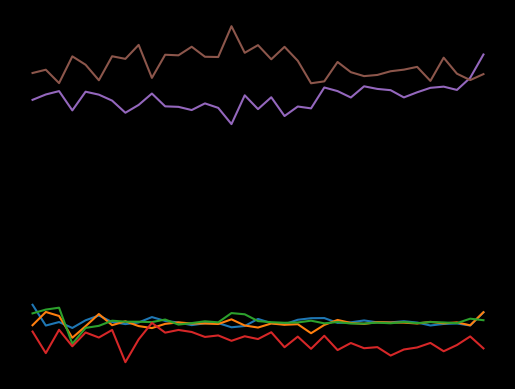

In [219]:
df_down_39 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(8)')

# 그래프 그리기
df_down_39.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

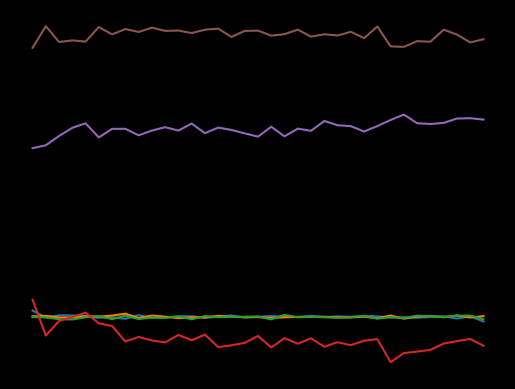

In [220]:
df_down_40 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(9)')

# 그래프 그리기
df_down_40.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

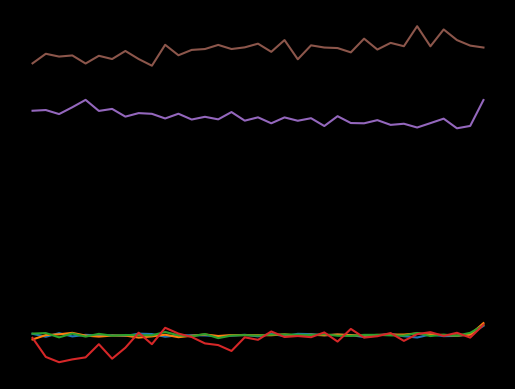

In [221]:
df_down_41 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(10)')

# 그래프 그리기
df_down_41.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

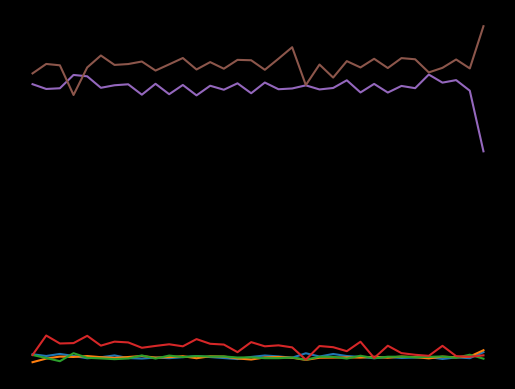

In [222]:
df_down_42 = pd.read_excel('에스컬레이터 측정 데이터.xlsx',sheet_name ='1 to b1 down(11)')

# 그래프 그리기
df_down_42.plot().get_legend().remove()

# 축 숨기기
plt.gca().set_axis_off()

# 전체 figure의 배경색을 black으로 설정
plt.gcf().set_facecolor('black')

# 그래프 출력
plt.show()

In [14]:
# 디렉토리 내 파일 확인
print(os.listdir(image_dir))  # 이미지 디렉토리 내 파일 목록 출력

['1_to_2_up(1).png', '1_to_2_up(10).png', '1_to_2_up(11).png', '1_to_2_up(12).png', '1_to_2_up(13).png', '1_to_2_up(14).png', '1_to_2_up(15).png', '1_to_2_up(16).png', '1_to_2_up(17).png', '1_to_2_up(18).png', '1_to_2_up(19).png', '1_to_2_up(2).png', '1_to_2_up(20).png', '1_to_2_up(21).png', '1_to_2_up(22).png', '1_to_2_up(23).png', '1_to_2_up(24).png', '1_to_2_up(3).png', '1_to_2_up(4).png', '1_to_2_up(5).png', '1_to_2_up(6).png', '1_to_2_up(7).png', '1_to_2_up(8).png', '1_to_2_up(9).png', '1_to_b1_down(1).png', '1_to_b1_down(10).png', '1_to_b1_down(11).png', '1_to_b1_down(2).png', '1_to_b1_down(3).png', '1_to_b1_down(4).png', '1_to_b1_down(5).png', '1_to_b1_down(6).png', '1_to_b1_down(7).png', '1_to_b1_down(8).png', '1_to_b1_down(9).png', '2_to_1_down(1).png', '2_to_1_down(10).png', '2_to_1_down(11).png', '2_to_1_down(12).png', '2_to_1_down(13).png', '2_to_1_down(14).png', '2_to_1_down(15).png', '2_to_1_down(16).png', '2_to_1_down(17).png', '2_to_1_down(18).png', '2_to_1_down(19).png

In [15]:
for filename in os.listdir(image_dir):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        # 파일명 분리
        file_name_without_ext = os.path.splitext(filename)[0]  # 확장자 제거
        parts = file_name_without_ext.split("_")  # "_" 기준으로 분할
        
        # 분할된 파일명 출력
        print(f"File: {filename} -> Parts: {parts}")


File: 1_to_2_up(1).png -> Parts: ['1', 'to', '2', 'up(1)']
File: 1_to_2_up(10).png -> Parts: ['1', 'to', '2', 'up(10)']
File: 1_to_2_up(11).png -> Parts: ['1', 'to', '2', 'up(11)']
File: 1_to_2_up(12).png -> Parts: ['1', 'to', '2', 'up(12)']
File: 1_to_2_up(13).png -> Parts: ['1', 'to', '2', 'up(13)']
File: 1_to_2_up(14).png -> Parts: ['1', 'to', '2', 'up(14)']
File: 1_to_2_up(15).png -> Parts: ['1', 'to', '2', 'up(15)']
File: 1_to_2_up(16).png -> Parts: ['1', 'to', '2', 'up(16)']
File: 1_to_2_up(17).png -> Parts: ['1', 'to', '2', 'up(17)']
File: 1_to_2_up(18).png -> Parts: ['1', 'to', '2', 'up(18)']
File: 1_to_2_up(19).png -> Parts: ['1', 'to', '2', 'up(19)']
File: 1_to_2_up(2).png -> Parts: ['1', 'to', '2', 'up(2)']
File: 1_to_2_up(20).png -> Parts: ['1', 'to', '2', 'up(20)']
File: 1_to_2_up(21).png -> Parts: ['1', 'to', '2', 'up(21)']
File: 1_to_2_up(22).png -> Parts: ['1', 'to', '2', 'up(22)']
File: 1_to_2_up(23).png -> Parts: ['1', 'to', '2', 'up(23)']
File: 1_to_2_up(24).png -> P

In [33]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

# 이미지 디렉토리 경로 (이미지 파일 경로로 수정)
image_dir = r"C:\Users\user\Desktop\donga5gi\train_image"  # 경로 수정

# 층 이동에 따른 레이블 설정 (파일명에 맞는 레이블 추가)
# 예시로 'b1_to_1', '1_to_2', '2_to_3' 형식도 처리
label_dict = {
    "b1_to_1": 0,
    "1_to_2": 1,
    "2_to_3": 2,
    "1_to_b1": 3,
    "2_to_1": 4,
    "3_to_2": 5
    # 더 추가할 수 있음
}

# 이미지와 레이블을 저장할 리스트
images = []
labels = []

# 디렉토리 내 이미지 파일 순회 (모든 이미지 처리)
for filename in os.listdir(image_dir):
    if filename.endswith(".png") or filename.endswith(".jpg"):  # 확장자 확인
        # 파일명에서 확장자 제거
        file_name_without_ext = os.path.splitext(filename)[0]  # 예: 'b1_to_1_up(1)', '1_to_2_up(1)'

        # 파일명에서 'up'과 'down'을 추출
        if "up" in file_name_without_ext:
            direction = "up"
        elif "down" in file_name_without_ext:
            direction = "down"
        else:
            continue  # 'up' 또는 'down'이 없으면 건너뛰기
        
        # 'b1_to_1', '1_to_2', '2_to_3' 등과 같은 층 이동 추출
        parts = file_name_without_ext.split("_")
        floor_move = parts[0] + "_to_" + parts[2]  # 예: 'b1_to_1', '1_to_2', '2_to_3'
        
        # 레이블이 label_dict에 존재하는지 확인
        if floor_move in label_dict:
            label = label_dict[floor_move]
            
            # 이미지 로드 및 전처리
            image_path = os.path.join(image_dir, filename)
            image = load_img(image_path, target_size=(224, 224), color_mode='grayscale')  # 흑백 이미지
            image_array = img_to_array(image) / 255.0  # 정규화 (0~1)
            
            # 이미지와 레이블을 리스트에 추가
            images.append(image_array)
            labels.append(label)
        else:
            print(f"Warning: Label not found for {filename}, floor_move: {floor_move}")

# 이미지 배열과 레이블 배열을 NumPy 배열로 변환
X = np.array(images)  # 이미지 배열
y = np.array(labels)  # 레이블 배열

# One-hot 인코딩 (3개 클래스 예시)
y_one_hot = to_categorical(y, num_classes=len(label_dict))

# 결과 확인
print(f"X shape: {X.shape}")  # (85, 224, 224, 1) -> 85개의 이미지
print(f"y shape: {y.shape}")  # (85,) -> 85개의 레이블
print(f"One-hot encoded y shape: {y_one_hot.shape}")  # (85, 3) -> One-hot 인코딩된 레이블


X shape: (85, 224, 224, 1)
y shape: (85,)
One-hot encoded y shape: (85, 6)


In [37]:
import os
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 이미지 디렉토리 경로
image_dir = r"C:\Users\user\Desktop\donga5gi\train_image"  # 경로 수정

# 층 이동에 따른 레이블 설정
label_dict = {
    "b1_to_1": 0,
    "1_to_2": 1,
    "2_to_3": 2,
    "1_to_b1": 3,
    "2_to_1": 4,
    "3_to_2": 5
}

# 이미지와 레이블을 저장할 리스트
images = []
labels = []

# 이미지 로드 및 레이블 설정
for filename in os.listdir(image_dir):
    if filename.endswith(".png") or filename.endswith(".jpg"):  # 확장자 확인
        # 파일명에서 확장자 제거
        file_name_without_ext = os.path.splitext(filename)[0]  # 예: 'b1_to_1_up(1)', '1_to_2_up(1)'
        
        # 'up' 또는 'down' 방향이 포함된 파일명을 확인
        if "up" in file_name_without_ext:
            direction = "up"
        elif "down" in file_name_without_ext:
            direction = "down"
        else:
            continue  # 'up' 또는 'down'이 없으면 건너뛰기
        
        # 파일명에서 층 이동 추출
        parts = file_name_without_ext.split("_")
        floor_move = parts[0] + "_to_" + parts[2]  # 예: 'b1_to_1', '1_to_2', '2_to_3'
        
        # 레이블이 label_dict에 존재하는지 확인
        if floor_move in label_dict:
            label = label_dict[floor_move]
            
            # 이미지 로드 및 전처리
            image_path = os.path.join(image_dir, filename)
            image = load_img(image_path, target_size=(224, 224), color_mode='grayscale')  # 흑백 이미지
            image_array = img_to_array(image) / 255.0  # 정규화 (0~1)
            
            # 이미지와 레이블을 리스트에 추가
            images.append(image_array)
            labels.append(label)
        else:
            print(f"Warning: Label not found for {filename}, floor_move: {floor_move}")

# 이미지 배열과 레이블 배열을 NumPy 배열로 변환
X = np.array(images)  # 이미지 배열
y = np.array(labels)  # 레이블 배열

# One-hot 인코딩 (3개 클래스 예시)
y_one_hot = to_categorical(y, num_classes=len(label_dict))

# 훈련 데이터와 검증 데이터 나누기 (80% 훈련, 20% 검증)
X_train, X_val, y_train, y_val = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# CNN 모델 설계
model = Sequential()

# 첫 번째 Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 두 번째 Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 세 번째 Convolutional Layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer (과적합 방지)
model.add(Dropout(0.5))

# 출력 Layer (6개의 클래스에 대한 확률 분포 출력)
model.add(Dense(len(label_dict), activation='softmax'))

# 모델 컴파일
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 모델 요약 출력
model.summary()

# 모델 훈련 (훈련 데이터와 검증 데이터 사용)
history = model.fit(
    X_train, y_train,           # 훈련 데이터
    epochs=10,                  # 학습 횟수
    batch_size=32,              # 배치 크기
    validation_data=(X_val, y_val),  # 검증 데이터
    verbose=1                   # 학습 진행상황 출력
)


C:\Users\user\.conda\envs\sky\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 222, 222, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,158 (42.61 MB)

 Trainable params: 11,169,158 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step - accuracy: 0.2466 - loss: 1.8452 - val_accuracy: 0.3529 - val_loss: 1.6876
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.3674 - loss: 1.6765 - val_accuracy: 0.3529 - val_loss: 1.6772
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.4242 - loss: 1.6211 - val_accuracy: 0.4118 - val_loss: 1.6370
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.4315 - loss: 1.4867 - val_accuracy: 0.4118 - val_loss: 1.6628
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step - accuracy: 0.4359 - loss: 1.4069 - val_accuracy: 0.4706 - val_loss: 1.6599
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.4770 - loss: 1.3122 - val_accuracy: 0.4118 - val_loss: 1.6870
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step - accuracy: 0.4467 - loss: 1.1154 - val_accuracy: 0.4118 - val_loss: 1.7123
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step - accuracy: 0.7162 - loss: 0.9390 - val_accuracy: 0.4706 - val_loss:

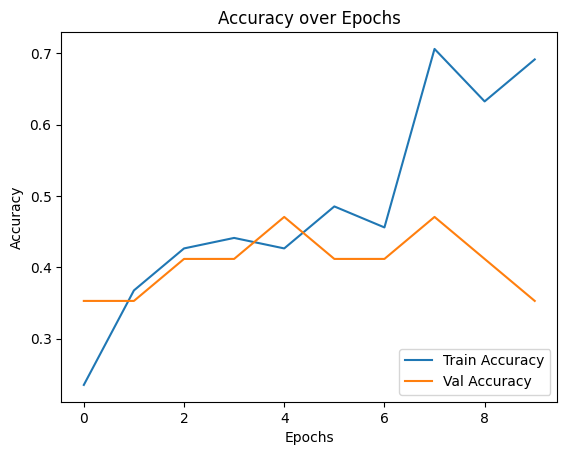

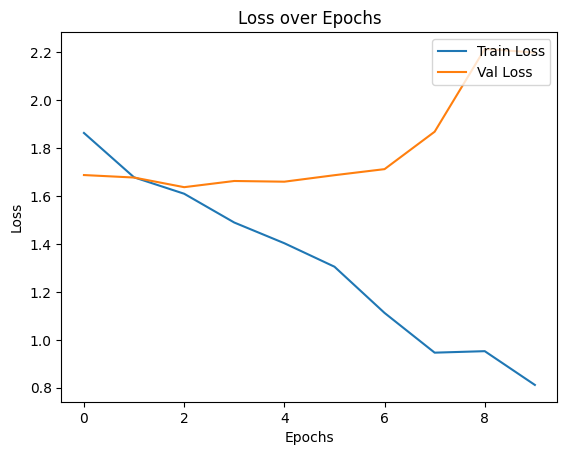

In [38]:
import matplotlib.pyplot as plt

# 훈련 정확도와 검증 정확도
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# 훈련 손실과 검증 손실
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


In [1]:
import pandas as pd

# 엑셀 파일 경로를 지정
file_path = '에스컬레이터 측정 데이터.xlsx'

# 엑셀 파일 읽기
data = pd.read_excel(file_path)

# 데이터 확인
print(data.head())


     gyro X    gyro Y    gyro Z   accel X   accel Y   accel Z
0 -0.343306  0.296728 -0.266032 -1.685518  5.813421  7.384017
1  0.166155 -0.044135  0.057727 -0.083797  6.962638  6.440702
2  0.023824  0.001069 -0.018021 -0.696713  6.768707  7.003339
3  0.000000 -0.018479 -0.007025 -0.466869  6.728006  7.008128
4  0.123395 -0.022755  0.043066 -0.402226  6.926725  6.660968


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

# 엑셀 파일 경로
file_path = '에스컬레이터 측정 데이터.xlsx'

# 엑셀 파일 열기
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names  # 모든 시트 이름 가져오기

# 빈 데이터프레임 생성
df_all = pd.DataFrame()

# 시트별로 데이터를 읽고 레이블 추가 후 결합
for i, sheet in enumerate(sheet_names):
    # 시트 데이터를 읽어오기
    df_sheet = pd.read_excel(xls, sheet_name=sheet)
    
    # 각 시트에 대한 레이블 추가 (문자열 결합 시 str() 사용)
    if '1 to 2 up' in sheet:
        df_sheet['label'] = '1_to_2_up_' + str(i + 1)  # 예: '1_to_2_up_1', '1_to_2_up_2'
    elif '2 to 3 up' in sheet:
        df_sheet['label'] = '2_to_3_up_' + str(i + 1)  # 예: '2_to_3_up_1', '2_to_3_up_2'
    elif '2 to 1 down' in sheet:
        df_sheet['label'] = '2_to_1_down_' + str(i + 1)  # 예: '2_to_1_down_1', '2_to_1_down_2'
    elif '3 to 2 down' in sheet:
        df_sheet['label'] = '3_to_2_down_' + str(i + 1)  # 예: '3_to_2_down_1', '3_to_2_down_2'
    elif '1 to b1 up' in sheet:
        df_sheet['label'] = '1_to_B1_up_' + str(i + 1)  # 예: '1_to_B1_up_1', '1_to_B1_up_2'
    elif 'b1 to 1 down' in sheet:
        df_sheet['label'] = 'B1_to_1_down_' + str(i + 1)  # 예: 'B1_to_1_down_1', 'B1_to_1_down_2'

    # 중복된 칼럼 제거
    df_sheet = df_sheet.loc[:, ~df_sheet.columns.duplicated()]
    
    # 각 시트의 데이터 크기 확인
    print(f"시트 {sheet}의 데이터 크기: {df_sheet.shape}")
    
    # 시트의 데이터를 세로로 결합 (행(row)으로 이어붙이기)
    df_all = pd.concat([df_all, df_sheet], axis=0, ignore_index=True)

# 결측치 처리 (결측치가 있을 경우 다른 방법으로 처리하거나 dropna를 변경)
print(f"원본 데이터 개수: {len(df_all)}")

시트 1 to 2 up(1)의 데이터 크기: (34, 7)
시트 1 to 2 up(24)의 데이터 크기: (31, 7)
시트 1 to 2 up(23)의 데이터 크기: (32, 7)
시트 1 to 2 up(22)의 데이터 크기: (31, 7)
시트 1 to 2 up(21)의 데이터 크기: (32, 7)
시트 1 to 2 up(20)의 데이터 크기: (32, 7)
시트 1 to 2 up(19)의 데이터 크기: (32, 7)
시트 1 to 2 up(18)의 데이터 크기: (32, 7)
시트 1 to 2 up(17)의 데이터 크기: (32, 7)
시트 1 to 2 up(16)의 데이터 크기: (31, 7)
시트 1 to 2 up(15)의 데이터 크기: (31, 7)
시트 1 to 2 up(14)의 데이터 크기: (33, 7)
시트 1 to 2 up(13)의 데이터 크기: (31, 7)
시트 1 to 2 up(12)의 데이터 크기: (32, 7)
시트 1 to 2 up(11)의 데이터 크기: (31, 7)
시트 1 to 2 up(10)의 데이터 크기: (32, 7)
시트 1 to 2 up(9)의 데이터 크기: (32, 7)
시트 1 to 2 up(8)의 데이터 크기: (31, 7)
시트 1 to 2 up(7)의 데이터 크기: (31, 7)
시트 1 to 2 up(6)의 데이터 크기: (31, 7)
시트 1 to 2 up(2)의 데이터 크기: (35, 7)
시트 1 to 2 up(3)의 데이터 크기: (35, 7)
시트 1 to 2 up(4)의 데이터 크기: (31, 7)
시트 1 to 2 up(5)의 데이터 크기: (31, 7)
시트 2 to 1 down(1)의 데이터 크기: (35, 7)
시트 2 to 1 down(23)의 데이터 크기: (31, 7)
시트 2 to 1 down(22)의 데이터 크기: (31, 7)
시트 2 to 1 down(21)의 데이터 크기: (31, 7)
시트 2 to 1 down(20)의 데이터 크기: (32, 7)
시트 2 to 1 down

In [2]:

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Load the enhanced dataset
data = pd.read_csv("enhanced_escalator_example.csv")

# Prepare features and labels
features = data.drop(columns=['direction'])
labels = data['direction']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\user\.conda\envs\sky\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\.conda\envs\sky\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\.conda\envs\sky\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\.conda\envs\sky\Lib

In [6]:
# Load the newly uploaded datasets for analysis
new_file_paths = {
    "data_down_1": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(1).csv",
    "data_down_2": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(2).csv",
    "data_down_3": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(3).csv",
    "data_down": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down.csv",
    "data_up_1": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_up(1).csv",
    "data_up_2": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_up(2).csv",
    "data_up_3": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(3).csv",
    "data_up": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_up.csv",
}

# Read the new data into DataFrames
new_data_frames = {name: pd.read_csv(path) for name, path in new_file_paths.items()}

# Display summary information for each new dataset
new_data_summaries = {name: df.describe(include='all') for name, df in new_data_frames.items()}

# Show the first few rows for each dataset
new_data_previews = {name: df.head() for name, df in new_data_frames.items()}

new_data_summaries, new_data_previews


({'data_down_1':                id       gyroX       gyroY       gyroZ      accelX      accelY  \
  count   383.00000  383.000000  383.000000  383.000000  383.000000  383.000000   
  unique        NaN         NaN         NaN         NaN         NaN         NaN   
  top           NaN         NaN         NaN         NaN         NaN         NaN   
  freq          NaN         NaN         NaN         NaN         NaN         NaN   
  mean    192.00000    0.005383   -0.003801    0.005717   -0.333832    6.325286   
  std     110.70682    0.066227    0.060007    0.066526    0.329719    0.420931   
  min       1.00000   -0.356745   -0.420428   -0.594066   -1.297657    4.833893   
  25%      96.50000   -0.022487   -0.018250   -0.011606   -0.561440    6.155792   
  50%     192.00000    0.001833   -0.002978    0.003360   -0.325611    6.395212   
  75%     287.50000    0.023213    0.013706    0.021686   -0.149638    6.613084   
  max     383.00000    0.517403    0.325668    0.434631    0.577003    7

In [1]:
import pandas as pd

# Load the uploaded CSV files
files = {
    "data_down_1": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(1).csv",
    "data_down_2": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(2).csv",
    "data_down_3": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(3).csv",
    "data_down": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down.csv",
    "data_up_1": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_up(1).csv",
    "data_up_2": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_up(2).csv",
    "data_up_3": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_down(3).csv",
    "data_up": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_up.csv",
    "data_walk": r"C:\Users\user\Desktop\donga5gi\새 폴더\data_walk.csv"
}

# Load the dataframes to inspect
dataframes = {name: pd.read_csv(path) for name, path in files.items()}
data_overview = {name: df.head() for name, df in dataframes.items()}
data_shapes = {name: df.shape for name, df in dataframes.items()}

data_overview, data_shapes


({'data_down_1':    id     gyroX     gyroY     gyroZ    accelX    accelY    accelZ  \
  0   1 -0.122173  0.202655  0.154854 -0.169988  6.062418  7.515698   
  1   2  0.051924 -0.001374  0.021075 -0.308852  6.711246  7.158962   
  2   3  0.004276 -0.002596  0.010690 -0.514753  6.639421  6.962638   
  3   4 -0.049480  0.005956  0.007025 -0.569820  6.627450  7.362470   
  4   5  0.024435 -0.006872  0.023518 -0.397437  6.811803  6.993762   
  
                      timestamp  
  0  2024-11-13T12:02:37.058732  
  1  2024-11-13T12:02:38.037667  
  2  2024-11-13T12:02:39.055610  
  3  2024-11-13T12:02:40.037827  
  4  2024-11-13T12:02:41.038048  ,
  'data_down_2':    id     gyroX     gyroY     gyroZ    accelX    accelY    accelZ  \
  0   1  0.070860 -0.173638 -0.170126 -0.284910  7.032070  6.977003   
  1   2  0.001222  0.041997 -0.059559 -0.440533  6.759130  6.785467   
  2   3  0.062919  0.054825  0.051007 -0.275333  7.053617  6.131850   
  3   4 -0.028711 -0.002596  0.019853 -0.160412  6.8

In [2]:
# Attempting to resolve the issue by ensuring all required libraries and data are reloaded correctly

# Reload necessary libraries and variables
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Reload datasets
data_walk = dataframes['data_walk']
data_down = pd.concat([
    dataframes['data_down'], 
    dataframes['data_down_1'], 
    dataframes['data_down_2'], 
    dataframes['data_down_3']
], ignore_index=True)
data_up = pd.concat([
    dataframes['data_up'], 
    dataframes['data_up_1'], 
    dataframes['data_up_2'], 
    dataframes['data_up_3']
], ignore_index=True)

# Assign labels: Walk (0), Down (1), Up (2)
data_walk['label'] = 0
data_down['label'] = 1
data_up['label'] = 2

# Combine all datasets
combined_data = pd.concat([data_walk, data_down, data_up], ignore_index=True)

# Define features and labels
features = ['gyroX', 'gyroY', 'gyroZ', 'accelX', 'accelY', 'accelZ']
X = combined_data[features]
y = combined_data['label']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=['Walk', 'Down', 'Up'])
conf_matrix = confusion_matrix(y_test, y_pred)

print(report, conf_matrix)


              precision    recall  f1-score   support

        Walk       1.00      1.00      1.00       631
        Down       0.64      0.64      0.64       842
          Up       0.62      0.62      0.62       800

    accuracy                           0.73      2273
   macro avg       0.75      0.75      0.75      2273
weighted avg       0.73      0.73      0.73      2273
 [[630   1   0]
 [  1 539 302]
 [  1 301 498]]


In [3]:
# Convert timestamp to datetime for time-based feature extraction
combined_data['timestamp'] = pd.to_datetime(combined_data['timestamp'])

# Sort by timestamp and calculate time difference (delta in seconds)
combined_data = combined_data.sort_values('timestamp').reset_index(drop=True)
combined_data['time_delta'] = combined_data['timestamp'].diff().dt.total_seconds().fillna(0)

# Calculate rate of change for each sensor data
for feature in ['gyroX', 'gyroY', 'gyroZ', 'accelX', 'accelY', 'accelZ']:
    combined_data[f'{feature}_diff'] = combined_data[feature].diff().fillna(0)

# Prepare features and labels
features = [
    'gyroX', 'gyroY', 'gyroZ', 'accelX', 'accelY', 'accelZ',
    'time_delta', 'gyroX_diff', 'gyroY_diff', 'gyroZ_diff',
    'accelX_diff', 'accelY_diff', 'accelZ_diff'
]
X = combined_data[features]
y = combined_data['label']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=['Walk', 'Down', 'Up'])
conf_matrix = confusion_matrix(y_test, y_pred)

print(report, conf_matrix)


              precision    recall  f1-score   support

        Walk       1.00      1.00      1.00       631
        Down       0.70      0.70      0.70       842
          Up       0.69      0.68      0.68       800

    accuracy                           0.78      2273
   macro avg       0.79      0.79      0.79      2273
weighted avg       0.78      0.78      0.78      2273
 [[631   0   0]
 [  1 591 250]
 [  1 254 545]]


Accuracy: 0.78
Precision: 0.78
Recall: 0.78
F1 Score: 0.78


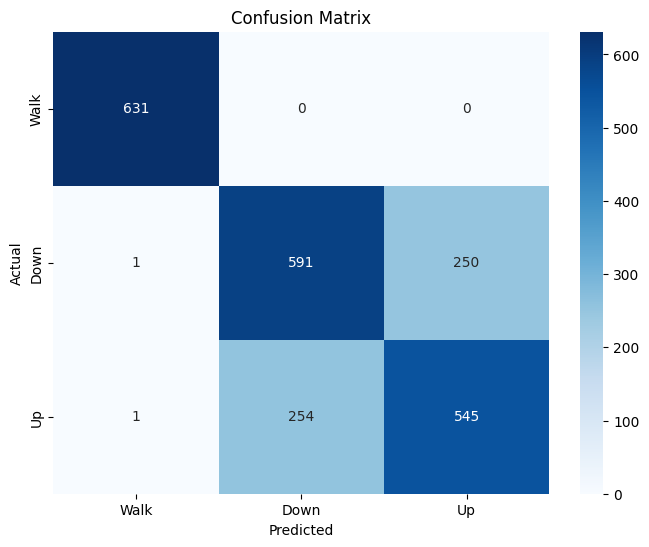

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
labels = ['Walk', 'Down', 'Up']

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [5]:
!pip install skl2onnx onnx

In [6]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# 모델 학습
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 모델 저장
joblib.dump(rf_model, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [7]:
import pickle

with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)


In [8]:
import os

# 현재 작업 디렉터리 확인
print("Current working directory:", os.getcwd())

# 모델 저장
model_path = os.path.join(os.getcwd(), "random_forest_model.pkl")
with open(model_path, 'wb') as file:
    pickle.dump(rf_model, file)

print("Model saved at:", model_path)


Current working directory: C:\Users\user\Desktop\donga5gi
Model saved at: C:\Users\user\Desktop\donga5gi\random_forest_model.pkl


In [24]:
from joblib import dump

# 모델 저장 경로 설정
model_path = r"C:\Users\Public\Documents\random_forest_model.pkl"

# Random Forest 모델 저장
dump(rf_model, model_path)

print(f"Model saved at: {model_path}")


Model saved at: C:\Users\Public\Documents\random_forest_model.pkl


In [8]:
import joblib
import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# 모델 로드
model = joblib.load(r"C:\Users\Public\Documents\random_forest_model.pkl")

# scikit-learn 모델을 ONNX로 변환
onnx_model = convert_sklearn(model, initial_types=[('input', FloatTensorType([None, 6]))])

# ONNX 모델 저장
onnx_model_path = r'C:\Users\Public\Documents\random_forest_model.onnx'
onnx.save_model(onnx_model, onnx_model_path)

# 변환된 ONNX 모델 경로 출력
print(f"ONNX 모델이 다음 경로에 저장되었습니다: {onnx_model_path}")


ONNX 모델이 다음 경로에 저장되었습니다: C:\Users\Public\Documents\random_forest_model.onnx


In [9]:
!pip install onnx-tf

In [10]:
!pip show onnx-tf

Name: onnx-tf
Version: 1.6.0
Summary: Tensorflow backend for ONNX (Open Neural Network Exchange).
Home-page: https://github.com/onnx/onnx-tensorflow/
Author: Arpith Jacob, Tian Jin, Gheorghe-Teodor Bercea, Wenhao Hu
Author-email: tian.jin1@ibm.com
License: Apache License 2.0
Location: C:\Users\user\.conda\envs\sky\Lib\site-packages
Requires: onnx, PyYAML
Required-by: 


In [11]:
!pip install --upgrade onnx-tf

  Using cached onnx_tf-1.10.0-py3-none-any.whl.metadata (510 bytes)
INFO: pip is looking at multiple versions of onnx-tf to determine which version is compatible with other requirements. This could take a while.
  Using cached onnx_tf-1.9.0-py3-none-any.whl.metadata (508 bytes)
  Using cached onnx_tf-1.8.0-py3-none-any.whl.metadata (508 bytes)
  Using cached onnx_tf-1.7.0-py3-none-any.whl.metadata (508 bytes)


In [17]:
!pip install onnx-tensorflow

ERROR: Could not find a version that satisfies the requirement onnx-tensorflow (from versions: none)
ERROR: No matching distribution found for onnx-tensorflow


In [23]:
import onnx

# ONNX 모델 로드
onnx_model = onnx.load(r'C:\Users\Public\Documents\random_forest_model.onnx')

In [ ]:
from flask import Flask, request, jsonify
import numpy as np
import pickle

app = Flask(__name__)

# 머신러닝 모델 로드
model_path = r"C:\Users\user\Desktop\donga5gi\random_forest_model.pkl"  # 또는 C:\Users\Public\Documents\random_forest_model.pkl
with open(model_path, "rb") as file:
    model = pickle.load(file)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 클라이언트에서 JSON 데이터 받기
        data = request.json
        gyro_data = data.get('gyro')  # 자이로스코프 데이터
        accel_data = data.get('accel')  # 가속도 데이터

        if gyro_data is None or accel_data is None:
            return jsonify({
                "status": "error",
                "message": "Missing 'gyro' or 'accel' data in request"
            }), 400

        # 입력 데이터 전처리
        input_data = np.array(gyro_data + accel_data).reshape(1, -1)

        # 모델 예측
        prediction = model.predict(input_data)
        
        # 예측 결과 매핑
        labels = ["walking", "escalator_up", "escalator_down"]
        result = labels[int(prediction[0])]

        return jsonify({
            "status": "success",
            "prediction": result
        })
    except Exception as e:
        return jsonify({
            "status": "error",
            "message": str(e)
        }), 400

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://10.104.24.236:5000
Press CTRL+C to quit
